# 🛡️ Hybrid Anomaly Detection — Learned Representations + Explicit Boundaries
## CSE-CIC-IDS2018 | Hybrid Phase | AWS t3.large Optimized | With Full Caching

**Project Goal:** Combine learned representations from Autoencoder variants with explicit anomaly boundary models (One-Class SVM, Isolation Forest, Random Forest) to build a robust hybrid IDS that outperforms each component alone.

**Hybrid Philosophy:**
- The Autoencoder learns a compact representation of "normal" traffic in latent space
- Boundary models (OC-SVM, IF, RF) draw explicit decision boundaries in that latent space
- Combining both gives: **low false positives** (boundary precision) + **high recall** (AE sensitivity)

**Models Evaluated:**
| # | Model | Idea |
|---|-------|------|
| 1 | **AE + One-Class SVM** | OC-SVM trained on AE bottleneck features (benign only) |
| 2 | **AE + Isolation Forest** | IF trained on AE bottleneck features (benign only) |
| 3 | **AE + RF (Pseudo-label)** | RF trained on pseudo-labels from AE threshold → re-scores with richer features |
| 4 | **Sparse AE + OC-SVM** | L1-regularised bottleneck → sparser, more separable latent space |
| 5 | **Denoising AE + OC-SVM** | Corruption-robust AE → more stable boundary |
| 6 | **Meta-Ensemble** | Weighted average of all anomaly scores → best overall |

**Pipeline:**
1. Load all existing caches from the autoencoder notebook (no data re-processing)
2. Extract bottleneck (latent) features from trained AE
3. Train boundary models on benign latent features only
4. Train RF using AE-generated pseudo-labels
5. Train AE variants (Sparse, Denoising) — cached
6. Evaluate all hybrids and compare

---
**Environment:** Ubuntu 24.04 | EC2 t3.large | 8GB RAM + 16GB swap | Python 3.10+

## Cell 1 — Install / Verify Dependencies

In [1]:
# ── Install dependencies (run once; safe to re-run) ───────────────────────────
# Uncomment if any packages are missing:
# !pip install numpy pandas scikit-learn tensorflow matplotlib seaborn tqdm pyarrow joblib --quiet

import sys, platform, os
import numpy as np
import pandas as pd
import tensorflow as tf
import sklearn, matplotlib, seaborn

print(f"Python     : {sys.version.split()[0]}")
print(f"Platform   : {platform.node()}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")
print(f"TensorFlow : {tf.__version__}")
print(f"Scikit     : {sklearn.__version__}")

mem_bytes = os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES')
print(f"\nSystem RAM : {mem_bytes / (1024**3):.1f} GB")

I0000 00:00:1777918505.718728    2889 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777918505.785203    2889 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777918510.013704    2889 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Python     : 3.12.3
Platform   : ip-172-31-94-241
NumPy      : 2.4.4
Pandas     : 3.0.2
TensorFlow : 2.21.0
Scikit     : 1.8.0

System RAM : 7.6 GB


## Cell 2 — Configuration & Cache Paths

Reuses the same directory structure as `cicids2018_autoencoder_ids.ipynb`.
All AE caches are read-only here; hybrid-specific outputs go to `outputs/hybrid/`.

In [2]:
import os

# ── Shared project paths (same as autoencoder notebook) ──────────────────────
DATA_PATH  = os.path.expanduser("~/ids2018/data")
OUTPUT_DIR = os.path.expanduser("~/ids2018/outputs")
CACHE_DIR  = os.path.expanduser("~/ids2018/cache")

# ── Hybrid-specific output sub-directory ─────────────────────────────────────
HYBRID_DIR = os.path.join(OUTPUT_DIR, "hybrid")
os.makedirs(HYBRID_DIR, exist_ok=True)

# ── Cache paths FROM autoencoder notebook (read-only, must exist) ─────────────
CACHE_X_TRAIN      = os.path.join(CACHE_DIR, "X_train_scaled.npy")
CACHE_X_VAL        = os.path.join(CACHE_DIR, "X_val_scaled.npy")
CACHE_X_ALL        = os.path.join(CACHE_DIR, "X_all_scaled.npy")
CACHE_Y_ALL        = os.path.join(CACHE_DIR, "y_all.npy")
CACHE_LABELS_ALL   = os.path.join(CACHE_DIR, "labels_all.npy")
CACHE_SCALER       = os.path.join(CACHE_DIR, "robust_scaler.joblib")
CACHE_AE_MODEL     = os.path.join(OUTPUT_DIR, "autoencoder_best.keras")
CACHE_RECON_ERRORS = os.path.join(CACHE_DIR, "recon_errors.npy")   # AE scores
CACHE_VAL_ERRORS   = os.path.join(CACHE_DIR, "val_errors.npy")     # for threshold

# ── Hybrid cache paths (written by this notebook) ────────────────────────────
CACHE_BOTTLENECK_TRAIN = os.path.join(CACHE_DIR, "bottleneck_train.npy")
CACHE_BOTTLENECK_ALL   = os.path.join(CACHE_DIR, "bottleneck_all.npy")
CACHE_BOTTLENECK_VAL   = os.path.join(CACHE_DIR, "bottleneck_val.npy")

CACHE_SPARSE_AE        = os.path.join(OUTPUT_DIR, "sparse_ae_best.keras")
CACHE_SPARSE_HISTORY   = os.path.join(CACHE_DIR,  "sparse_ae_history.npy")
CACHE_SPARSE_ERRORS    = os.path.join(CACHE_DIR,  "sparse_ae_recon_errors.npy")
CACHE_SPARSE_VAL_ERR   = os.path.join(CACHE_DIR,  "sparse_ae_val_errors.npy")
CACHE_SPARSE_BN_TRAIN  = os.path.join(CACHE_DIR,  "sparse_bottleneck_train.npy")
CACHE_SPARSE_BN_ALL    = os.path.join(CACHE_DIR,  "sparse_bottleneck_all.npy")
CACHE_SPARSE_BN_VAL    = os.path.join(CACHE_DIR,  "sparse_bottleneck_val.npy")

CACHE_DAE_MODEL        = os.path.join(OUTPUT_DIR, "denoising_ae_best.keras")
CACHE_DAE_HISTORY      = os.path.join(CACHE_DIR,  "dae_history.npy")
CACHE_DAE_ERRORS       = os.path.join(CACHE_DIR,  "dae_recon_errors.npy")
CACHE_DAE_VAL_ERR      = os.path.join(CACHE_DIR,  "dae_val_errors.npy")
CACHE_DAE_BN_TRAIN     = os.path.join(CACHE_DIR,  "dae_bottleneck_train.npy")
CACHE_DAE_BN_ALL       = os.path.join(CACHE_DIR,  "dae_bottleneck_all.npy")
CACHE_DAE_BN_VAL       = os.path.join(CACHE_DIR,  "dae_bottleneck_val.npy")

# ── Hybrid model joblib caches ────────────────────────────────────────────────
CACHE_OCSVM_AE         = os.path.join(CACHE_DIR, "ocsvm_ae_bottleneck.joblib")
CACHE_IF_AE            = os.path.join(CACHE_DIR, "iforest_ae_bottleneck.joblib")
CACHE_RF_PSEUDO        = os.path.join(CACHE_DIR, "rf_pseudo_label.joblib")
CACHE_OCSVM_SPARSE     = os.path.join(CACHE_DIR, "ocsvm_sparse_bottleneck.joblib")
CACHE_OCSVM_DAE        = os.path.join(CACHE_DIR, "ocsvm_dae_bottleneck.joblib")

# ── Hyperparameters ───────────────────────────────────────────────────────────
FORCE_RERUN          = False    # set True to ignore all hybrid caches

# Autoencoder architecture (must match the trained AE)
ENCODING_DIM         = 32
HIDDEN_DIMS          = [128, 64]
DROPOUT_RATE         = 0.2
BATCH_SIZE           = 512
AE_EPOCHS            = 50
LEARNING_RATE        = 1e-3
THRESHOLD_PERCENTILE = 99

# OC-SVM
OCSVM_NU             = 0.05     # expected fraction of outliers (~5%)
OCSVM_KERNEL         = "rbf"

# Isolation Forest
IF_N_ESTIMATORS      = 200
IF_CONTAMINATION     = 0.05

# RF (pseudo-label)
RF_N_ESTIMATORS      = 200
RF_MAX_DEPTH         = 12

# Sparse AE: L1 activity regularisation on bottleneck
SPARSE_L1            = 1e-4

# Denoising AE: Gaussian noise std added to inputs during training
DAE_NOISE_STD        = 0.1

SEED = 42

print(f"Output dir   : {OUTPUT_DIR}")
print(f"Hybrid dir   : {HYBRID_DIR}")
print(f"Cache dir    : {CACHE_DIR}")
print(f"FORCE_RERUN  : {FORCE_RERUN}")

Output dir   : /home/ubuntu/ids2018/outputs
Hybrid dir   : /home/ubuntu/ids2018/outputs/hybrid
Cache dir    : /home/ubuntu/ids2018/cache
FORCE_RERUN  : False


## Cell 3 — Imports

In [3]:
import warnings, gc, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
from tqdm import tqdm
from IPython.display import Image, display

from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks, regularizers

import matplotlib
matplotlib.use("Agg")  # headless AWS — plots saved then displayed inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)
FIGSIZE = (10, 5)

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("All imports successful ✓")

All imports successful ✓


## Cell 4 — Helper Utilities (plot, cache, metrics)

In [4]:
# ── Plot helper ───────────────────────────────────────────────────────────────
def save_and_show(fig, filename: str, subdir: str = "hybrid"):
    """Save figure to outputs/<subdir>/ and display inline."""
    out_dir = os.path.join(OUTPUT_DIR, subdir)
    os.makedirs(out_dir, exist_ok=True)
    path = os.path.join(out_dir, filename)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=path))
    print(f"Saved: {path}")


# ── Cache helper ──────────────────────────────────────────────────────────────
def cache_exists(*paths) -> bool:
    if FORCE_RERUN:
        return False
    return all(os.path.exists(p) for p in paths)


# ── Unified metrics helper ────────────────────────────────────────────────────
def evaluate_scores(scores: np.ndarray, y_true: np.ndarray,
                    val_scores: np.ndarray, model_name: str,
                    percentile: int = THRESHOLD_PERCENTILE) -> dict:
    """
    Given raw anomaly scores (higher = more anomalous), compute:
      - ROC-AUC, Average Precision, F1 at percentile threshold
      - TP, TN, FP, FN, Recall (TPR), FPR
    Uses val_scores (benign-only) to calibrate the threshold.
    Returns a dict and prints a summary.
    """
    threshold   = float(np.percentile(val_scores, percentile))
    y_pred      = (scores > threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    precision   = tp / (tp + fp + 1e-10)
    recall      = tp / (tp + fn + 1e-10)
    fpr         = fp / (fp + tn + 1e-10)
    f1          = 2 * precision * recall / (precision + recall + 1e-10)
    accuracy    = (tp + tn) / len(y_true)
    auc_roc     = roc_auc_score(y_true, scores)
    avg_prec    = average_precision_score(y_true, scores)

    result = dict(
        model=model_name, threshold=threshold,
        roc_auc=auc_roc, avg_precision=avg_prec,
        f1=f1, recall=recall, precision=precision,
        fpr=fpr, accuracy=accuracy,
        tp=tp, tn=tn, fp=fp, fn=fn
    )

    print(f"\n{'='*56}")
    print(f"  {model_name}")
    print(f"{'='*56}")
    print(f"  ROC-AUC          : {auc_roc:.4f}")
    print(f"  Avg Precision    : {avg_prec:.4f}")
    print(f"  F1 Score         : {f1:.4f}")
    print(f"  Recall (TPR)     : {recall:.4f}")
    print(f"  Precision        : {precision:.4f}")
    print(f"  False Pos Rate   : {fpr:.4f}")
    print(f"  Accuracy         : {accuracy:.4f}")
    print(f"  Threshold (P{percentile}): {threshold:.6f}")
    print(f"  TP={tp:,}  TN={tn:,}  FP={fp:,}  FN={fn:,}")
    return result


print("Helpers ready ✓")

Helpers ready ✓


## Cell 5 — Load Existing Caches (from Autoencoder Notebook)

**All expensive data processing is already done.**
We load the pre-scaled arrays and the trained AE directly — no CSV loading or re-scaling.

In [5]:
required = [
    CACHE_X_TRAIN, CACHE_X_VAL, CACHE_X_ALL,
    CACHE_Y_ALL, CACHE_LABELS_ALL, CACHE_AE_MODEL,
    CACHE_RECON_ERRORS, CACHE_VAL_ERRORS
]
missing = [p for p in required if not os.path.exists(p)]
if missing:
    raise FileNotFoundError(
        f"Missing cache files from autoencoder notebook:\n"
        + "\n".join(f"  {p}" for p in missing)
        + "\n\nPlease run cicids2018_autoencoder_ids.ipynb first."
    )

t0 = time.time()
print("Loading pre-built caches...")

X_train_scaled  = np.load(CACHE_X_TRAIN)
X_val_scaled    = np.load(CACHE_X_VAL)
X_all_scaled    = np.load(CACHE_X_ALL)
y_all           = np.load(CACHE_Y_ALL)
labels_all      = np.load(CACHE_LABELS_ALL, allow_pickle=True)
ae_recon_errors = np.load(CACHE_RECON_ERRORS)   # standard AE anomaly scores
ae_val_errors   = np.load(CACHE_VAL_ERRORS)     # benign-only val errors
scaler          = joblib.load(CACHE_SCALER)

print(f"  Loaded in {time.time()-t0:.1f}s")
print(f"  X_train : {X_train_scaled.shape}")
print(f"  X_val   : {X_val_scaled.shape}")
print(f"  X_all   : {X_all_scaled.shape}")

INPUT_DIM = X_train_scaled.shape[1]
n_benign  = (y_all == 0).sum()
n_attack  = (y_all == 1).sum()
print(f"  Input dim: {INPUT_DIM}")
print(f"  Benign: {n_benign:,}  |  Attack: {n_attack:,}")

# ── Load trained standard AE ──────────────────────────────────────────────────
print(f"\nLoading trained AE from: {CACHE_AE_MODEL}")
standard_ae = keras.models.load_model(CACHE_AE_MODEL)
print("  AE loaded ✓")

# ── Standard AE threshold (P99 on benign val errors) ─────────────────────────
AE_THRESHOLD = float(np.percentile(ae_val_errors, THRESHOLD_PERCENTILE))
print(f"\nStandard AE threshold (P{THRESHOLD_PERCENTILE}): {AE_THRESHOLD:.6f}")

Loading pre-built caches...
  Loaded in 10.6s
  X_train : (1640626, 68)
  X_val   : (410157, 68)
  X_all   : (3215110, 68)
  Input dim: 68
  Benign: 2,050,783  |  Attack: 1,164,327

Loading trained AE from: /home/ubuntu/ids2018/outputs/autoencoder_best.keras


E0000 00:00:1777918524.540024    2889 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


  AE loaded ✓

Standard AE threshold (P99): 0.970072


## Cell 6 — Build Encoder Extractor (Bottleneck Features)

We create a sub-model that outputs only the **bottleneck layer** of the trained AE.
This gives a compact 32-dim representation of each traffic flow.
Boundary models (OC-SVM, IF, RF) will operate in this latent space.

In [6]:
def build_encoder_extractor(ae_model: keras.Model) -> keras.Model:
    """Return a sub-model that outputs the 'bottleneck' layer of a given AE."""
    bottleneck_layer = ae_model.get_layer("bottleneck")
    return keras.Model(
        inputs=ae_model.input,
        outputs=bottleneck_layer.output,
        name="encoder_extractor"
    )


ae_encoder = build_encoder_extractor(standard_ae)
print(f"Encoder extractor: {INPUT_DIM}D input → {ENCODING_DIM}D bottleneck")

# ── Extract bottleneck features (cached) ──────────────────────────────────────
if cache_exists(CACHE_BOTTLENECK_TRAIN, CACHE_BOTTLENECK_ALL, CACHE_BOTTLENECK_VAL):
    print("\nCACHE HIT — loading bottleneck features...")
    t0 = time.time()
    bn_train = np.load(CACHE_BOTTLENECK_TRAIN)
    bn_all   = np.load(CACHE_BOTTLENECK_ALL)
    bn_val   = np.load(CACHE_BOTTLENECK_VAL)
    print(f"  Loaded in {time.time()-t0:.1f}s")
else:
    print("\nCACHE MISS — extracting bottleneck features...")
    t0 = time.time()
    bn_train = ae_encoder.predict(X_train_scaled, batch_size=4096, verbose=1).astype(np.float32)
    bn_all   = ae_encoder.predict(X_all_scaled,   batch_size=4096, verbose=1).astype(np.float32)
    bn_val   = ae_encoder.predict(X_val_scaled,   batch_size=4096, verbose=1).astype(np.float32)
    np.save(CACHE_BOTTLENECK_TRAIN, bn_train)
    np.save(CACHE_BOTTLENECK_ALL,   bn_all)
    np.save(CACHE_BOTTLENECK_VAL,   bn_val)
    print(f"  Extracted and saved in {time.time()-t0:.1f}s")

print(f"\nBottleneck shapes:")
print(f"  Train (benign): {bn_train.shape}")
print(f"  Val   (benign): {bn_val.shape}")
print(f"  All   (mixed) : {bn_all.shape}")

Encoder extractor: 68D input → 32D bottleneck

CACHE HIT — loading bottleneck features...
  Loaded in 4.8s

Bottleneck shapes:
  Train (benign): (1640626, 32)
  Val   (benign): (410157, 32)
  All   (mixed) : (3215110, 32)


## Cell 7 — Baseline Reference: Standard AE Alone

Record the standalone AE performance so we can compare hybrid improvements.

In [7]:
all_results = []   # list of dicts; one per model

result_ae = evaluate_scores(
    scores     = ae_recon_errors,
    y_true     = y_all,
    val_scores = ae_val_errors,
    model_name = "Baseline: Standard AE"
)
all_results.append(result_ae)

print("\n(Baseline recorded — will appear in final comparison table)")


  Baseline: Standard AE
  ROC-AUC          : 0.8965
  Avg Precision    : 0.7578
  F1 Score         : 0.0336
  Recall (TPR)     : 0.0174
  Precision        : 0.5012
  False Pos Rate   : 0.0098
  Accuracy         : 0.6379
  Threshold (P99): 0.970072
  TP=20,241  TN=2,030,639  FP=20,144  FN=1,144,086

(Baseline recorded — will appear in final comparison table)


## Cell 8 — Hybrid 1: Standard AE + One-Class SVM

**Strategy:** Train OC-SVM on the AE's 32-dim bottleneck features of **benign-only** data.
OC-SVM learns an RBF hypersphere around normal latent points.

**Final anomaly score:** `α × AE_recon_error + (1-α) × OC-SVM_distance`
(both normalised to [0,1] before combining)

In [8]:
# ── Train / load OC-SVM ───────────────────────────────────────────────────────
if cache_exists(CACHE_OCSVM_AE):
    print("CACHE HIT — loading OC-SVM (AE bottleneck)...")
    ocsvm_ae = joblib.load(CACHE_OCSVM_AE)
else:
    print("CACHE MISS — training OC-SVM on AE bottleneck (benign train)...")
    t0 = time.time()
    # NOTE: OC-SVM scales quadratically → subsample large training sets
    MAX_OCSVM_TRAIN = 80_000
    if len(bn_train) > MAX_OCSVM_TRAIN:
        idx = np.random.choice(len(bn_train), MAX_OCSVM_TRAIN, replace=False)
        bn_train_sub = bn_train[idx]
        print(f"  Subsampled to {MAX_OCSVM_TRAIN:,} benign rows for OC-SVM speed")
    else:
        bn_train_sub = bn_train

    ocsvm_ae = OneClassSVM(kernel=OCSVM_KERNEL, nu=OCSVM_NU, gamma="scale")
    ocsvm_ae.fit(bn_train_sub)
    joblib.dump(ocsvm_ae, CACHE_OCSVM_AE)
    print(f"  Trained in {time.time()-t0:.1f}s  |  saved: {CACHE_OCSVM_AE}")

# ── Score all samples ─────────────────────────────────────────────────────────
# decision_function returns signed distances; negative = anomalous
# We negate so that higher = more anomalous (consistent with recon error convention)
print("Scoring all samples with OC-SVM...")
ocsvm_ae_raw_scores = -ocsvm_ae.decision_function(bn_all)  # higher = more anomalous
ocsvm_ae_val_scores = -ocsvm_ae.decision_function(bn_val)

# ── Normalise both scores to [0,1] then combine ───────────────────────────────
def min_max_norm(arr, ref_arr=None):
    """Min-max normalise arr; use ref_arr min/max if provided (for val set)."""
    lo = ref_arr.min() if ref_arr is not None else arr.min()
    hi = ref_arr.max() if ref_arr is not None else arr.max()
    return np.clip((arr - lo) / (hi - lo + 1e-10), 0, 1)

ae_norm_all  = min_max_norm(ae_recon_errors)
ae_norm_val  = min_max_norm(ae_val_errors,  ae_val_errors)
oc_norm_all  = min_max_norm(ocsvm_ae_raw_scores)
oc_norm_val  = min_max_norm(ocsvm_ae_val_scores, ocsvm_ae_raw_scores)

ALPHA = 0.5   # equal weight; tune if needed
hybrid1_scores     = ALPHA * ae_norm_all + (1 - ALPHA) * oc_norm_all
hybrid1_val_scores = ALPHA * ae_norm_val + (1 - ALPHA) * oc_norm_val

result_h1 = evaluate_scores(
    scores     = hybrid1_scores,
    y_true     = y_all,
    val_scores = hybrid1_val_scores,
    model_name = "Hybrid 1: AE + OC-SVM (bottleneck)"
)
all_results.append(result_h1)

CACHE HIT — loading OC-SVM (AE bottleneck)...
Scoring all samples with OC-SVM...

  Hybrid 1: AE + OC-SVM (bottleneck)
  ROC-AUC          : 0.4600
  Avg Precision    : 0.3137
  F1 Score         : 0.0094
  Recall (TPR)     : 0.0048
  Precision        : 0.2127
  False Pos Rate   : 0.0101
  Accuracy         : 0.6332
  Threshold (P99): 0.299575
  TP=5,575  TN=2,030,153  FP=20,630  FN=1,158,752


## Cell 9 — Hybrid 2: Standard AE + Isolation Forest

**Strategy:** Isolation Forest on the AE 32-dim bottleneck.
IF is faster than OC-SVM, scales to large datasets, and performs well on high-dimensional data.

**Final score:** `α × AE_recon_error + (1-α) × IF_anomaly_score`

In [9]:
# ── Train / load Isolation Forest ─────────────────────────────────────────────
if cache_exists(CACHE_IF_AE):
    print("CACHE HIT — loading Isolation Forest (AE bottleneck)...")
    if_ae = joblib.load(CACHE_IF_AE)
else:
    print("CACHE MISS — training Isolation Forest on AE bottleneck (benign train)...")
    t0 = time.time()
    if_ae = IsolationForest(
        n_estimators=IF_N_ESTIMATORS,
        contamination=IF_CONTAMINATION,
        random_state=SEED,
        n_jobs=-1
    )
    if_ae.fit(bn_train)   # benign-only bottleneck features
    joblib.dump(if_ae, CACHE_IF_AE)
    print(f"  Trained in {time.time()-t0:.1f}s  |  saved: {CACHE_IF_AE}")

# ── Score: IF returns negative anomaly scores (lower = more anomalous) → negate
print("Scoring all samples with Isolation Forest...")
if_raw_all  = -if_ae.score_samples(bn_all)
if_raw_val  = -if_ae.score_samples(bn_val)

# ── Combine ───────────────────────────────────────────────────────────────────
if_norm_all = min_max_norm(if_raw_all)
if_norm_val = min_max_norm(if_raw_val, if_raw_all)

hybrid2_scores     = ALPHA * ae_norm_all + (1 - ALPHA) * if_norm_all
hybrid2_val_scores = ALPHA * ae_norm_val + (1 - ALPHA) * if_norm_val

result_h2 = evaluate_scores(
    scores     = hybrid2_scores,
    y_true     = y_all,
    val_scores = hybrid2_val_scores,
    model_name = "Hybrid 2: AE + Isolation Forest (bottleneck)"
)
all_results.append(result_h2)

CACHE HIT — loading Isolation Forest (AE bottleneck)...
Scoring all samples with Isolation Forest...

  Hybrid 2: AE + Isolation Forest (bottleneck)
  ROC-AUC          : 0.4231
  Avg Precision    : 0.3392
  F1 Score         : 0.0116
  Recall (TPR)     : 0.0060
  Precision        : 0.2508
  False Pos Rate   : 0.0101
  Accuracy         : 0.6336
  Threshold (P99): 0.371899
  TP=6,938  TN=2,030,056  FP=20,727  FN=1,157,389


## Cell 10 — Hybrid 3: AE + Random Forest (Pseudo-Label)

**Strategy (semi-supervised):**
1. Apply AE threshold to the full scaled dataset → generate pseudo-labels (0=normal, 1=anomaly)
2. Train a Random Forest **classifier** on these pseudo-labels using the **original 80-dim features**
3. RF learns richer, non-linear decision boundaries from the raw feature space
4. RF's `predict_proba` becomes the final anomaly score

**Why this helps:** RF corrects AE mistakes — features that AE misses can still be
caught by RF's tree splits. The combination improves precision (fewer FP) while maintaining recall.

In [10]:
# Step 1: Generate pseudo-labels using AE threshold on training + val benign set
# We pseudo-label the ENTIRE X_all_scaled for RF training
ae_pseudo_labels = (ae_recon_errors > AE_THRESHOLD).astype(int)

n_pseudo_pos = ae_pseudo_labels.sum()
n_pseudo_neg = (ae_pseudo_labels == 0).sum()
print(f"Pseudo-label distribution:")
print(f"  Pseudo-benign (0) : {n_pseudo_neg:,}")
print(f"  Pseudo-attack (1) : {n_pseudo_pos:,}")
print(f"  True attack count : {n_attack:,}  (for reference)")

# ── Train / load RF ───────────────────────────────────────────────────────────
if cache_exists(CACHE_RF_PSEUDO):
    print("\nCACHE HIT — loading RF (pseudo-label)...")
    rf_pseudo = joblib.load(CACHE_RF_PSEUDO)
else:
    print("\nCACHE MISS — training RF on pseudo-labels...")
    # Subsample for speed if dataset is very large (RF on 3M rows is slow)
    MAX_RF_TRAIN = 500_000
    if len(X_all_scaled) > MAX_RF_TRAIN:
        idx = np.random.choice(len(X_all_scaled), MAX_RF_TRAIN, replace=False)
        X_rf_train = X_all_scaled[idx]
        y_rf_train = ae_pseudo_labels[idx]
        print(f"  Subsampled to {MAX_RF_TRAIN:,} rows for RF training")
    else:
        X_rf_train = X_all_scaled
        y_rf_train = ae_pseudo_labels

    t0 = time.time()
    rf_pseudo = RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS,
        max_depth=RF_MAX_DEPTH,
        class_weight="balanced",   # handles pseudo-label imbalance
        random_state=SEED,
        n_jobs=-1
    )
    rf_pseudo.fit(X_rf_train, y_rf_train)
    joblib.dump(rf_pseudo, CACHE_RF_PSEUDO)
    print(f"  Trained in {time.time()-t0:.1f}s  |  saved: {CACHE_RF_PSEUDO}")

# ── RF anomaly scores (probability of being attack class) ─────────────────────
print("Scoring with RF...")
rf_scores_all = rf_pseudo.predict_proba(X_all_scaled)[:, 1]
rf_scores_val = rf_pseudo.predict_proba(X_val_scaled)[:, 1]

# ── Combine RF + AE scores ────────────────────────────────────────────────────
rf_norm_all = min_max_norm(rf_scores_all)
rf_norm_val = min_max_norm(rf_scores_val, rf_scores_all)

hybrid3_scores     = ALPHA * ae_norm_all + (1 - ALPHA) * rf_norm_all
hybrid3_val_scores = ALPHA * ae_norm_val + (1 - ALPHA) * rf_norm_val

result_h3 = evaluate_scores(
    scores     = hybrid3_scores,
    y_true     = y_all,
    val_scores = hybrid3_val_scores,
    model_name = "Hybrid 3: AE + RF (pseudo-label)"
)
all_results.append(result_h3)

# Also evaluate RF alone for reference
result_rf_alone = evaluate_scores(
    scores     = rf_scores_all,
    y_true     = y_all,
    val_scores = rf_scores_val,
    model_name = "Reference: RF alone (pseudo-label)"
)
all_results.append(result_rf_alone)

Pseudo-label distribution:
  Pseudo-benign (0) : 3,174,725
  Pseudo-attack (1) : 40,385
  True attack count : 1,164,327  (for reference)

CACHE HIT — loading RF (pseudo-label)...
Scoring with RF...

  Hybrid 3: AE + RF (pseudo-label)
  ROC-AUC          : 0.7920
  Avg Precision    : 0.5593
  F1 Score         : 0.0335
  Recall (TPR)     : 0.0174
  Precision        : 0.4976
  False Pos Rate   : 0.0099
  Accuracy         : 0.6378
  Threshold (P99): 0.375910
  TP=20,210  TN=2,030,382  FP=20,401  FN=1,144,117

  Reference: RF alone (pseudo-label)
  ROC-AUC          : 0.3433
  Avg Precision    : 0.3176
  F1 Score         : 0.0335
  Recall (TPR)     : 0.0173
  Precision        : 0.4978
  False Pos Rate   : 0.0099
  Accuracy         : 0.6378
  Threshold (P99): 0.704795
  TP=20,189  TN=2,030,413  FP=20,370  FN=1,144,138


## Cell 11 — Build AE Variants (Sparse & Denoising)

**Sparse AE:** Adds L1 activity regularisation on the bottleneck layer.
Forces sparse activations → fewer but more meaningful latent dimensions.
Better separability for OC-SVM.

**Denoising AE:** Adds Gaussian noise to inputs during training but trains on clean targets.
Forces the encoder to learn robust, noise-invariant features.
More stable boundary in latent space.

In [11]:
def build_sparse_ae(input_dim, hidden_dims, encoding_dim, dropout_rate, l1_reg):
    """
    Deep AE with L1 activity regularisation on the bottleneck.
    Architecture identical to standard AE except the bottleneck activation
    has an L1 penalty that pushes most units toward 0.
    """
    inp = keras.Input(shape=(input_dim,), name="input")
    x = inp
    for i, units in enumerate(hidden_dims):
        x = layers.Dense(units,           name=f"enc_dense_{i}")(x)
        x = layers.BatchNormalization(    name=f"enc_bn_{i}")(x)
        x = layers.Activation("relu",    name=f"enc_relu_{i}")(x)
        x = layers.Dropout(dropout_rate, name=f"enc_drop_{i}")(x)

    bottleneck = layers.Dense(
        encoding_dim,
        activation="relu",
        activity_regularizer=regularizers.l1(l1_reg),   # ← sparsity penalty
        name="bottleneck"
    )(x)

    x = bottleneck
    for i, units in enumerate(reversed(hidden_dims)):
        x = layers.Dense(units,           name=f"dec_dense_{i}")(x)
        x = layers.BatchNormalization(    name=f"dec_bn_{i}")(x)
        x = layers.Activation("relu",    name=f"dec_relu_{i}")(x)
        x = layers.Dropout(dropout_rate, name=f"dec_drop_{i}")(x)

    output = layers.Dense(input_dim, activation="linear", name="reconstruction")(x)
    model  = Model(inputs=inp, outputs=output, name="SparseAutoencoder")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="mse", metrics=["mae"]
    )
    return model


def build_denoising_ae(input_dim, hidden_dims, encoding_dim, dropout_rate, noise_std):
    """
    Denoising AE: a GaussianNoise layer is inserted immediately after the input.
    During training the model must recover clean inputs from corrupted ones.
    During inference (model.predict), GaussianNoise is disabled automatically.
    """
    inp    = keras.Input(shape=(input_dim,), name="input")
    noisy  = layers.GaussianNoise(noise_std, name="noise")(inp)   # active only in training
    x      = noisy
    for i, units in enumerate(hidden_dims):
        x = layers.Dense(units,           name=f"enc_dense_{i}")(x)
        x = layers.BatchNormalization(    name=f"enc_bn_{i}")(x)
        x = layers.Activation("relu",    name=f"enc_relu_{i}")(x)
        x = layers.Dropout(dropout_rate, name=f"enc_drop_{i}")(x)

    bottleneck = layers.Dense(encoding_dim, activation="relu", name="bottleneck")(x)

    x = bottleneck
    for i, units in enumerate(reversed(hidden_dims)):
        x = layers.Dense(units,           name=f"dec_dense_{i}")(x)
        x = layers.BatchNormalization(    name=f"dec_bn_{i}")(x)
        x = layers.Activation("relu",    name=f"dec_relu_{i}")(x)
        x = layers.Dropout(dropout_rate, name=f"dec_drop_{i}")(x)

    output = layers.Dense(input_dim, activation="linear", name="reconstruction")(x)
    model  = Model(inputs=inp, outputs=output, name="DenoisingAutoencoder")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="mse", metrics=["mae"]
    )
    return model


def get_ae_callbacks(model_path):
    return [
        callbacks.EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
        callbacks.ModelCheckpoint(filepath=model_path, monitor="val_loss", save_best_only=True, verbose=0)
    ]


print(f"Sparse AE   : L1={SPARSE_L1}  on bottleneck activity")
print(f"Denoising AE: Gaussian noise std={DAE_NOISE_STD} on inputs during training")

Sparse AE   : L1=0.0001  on bottleneck activity
Denoising AE: Gaussian noise std=0.1 on inputs during training


## Cell 12 — Train Sparse AE *(cached)*

In [12]:
if cache_exists(CACHE_SPARSE_AE, CACHE_SPARSE_HISTORY):
    print("CACHE HIT — loading Sparse AE...")
    sparse_ae    = keras.models.load_model(CACHE_SPARSE_AE)
    sparse_hist  = np.load(CACHE_SPARSE_HISTORY, allow_pickle=True).item()
    sparse_best_epoch = int(np.argmin(sparse_hist["val_loss"])) + 1
    print(f"  Best epoch: {sparse_best_epoch}  |  Best val MSE: {min(sparse_hist['val_loss']):.6f}")
else:
    print("CACHE MISS — training Sparse AE...")
    sparse_ae = build_sparse_ae(INPUT_DIM, HIDDEN_DIMS, ENCODING_DIM, DROPOUT_RATE, SPARSE_L1)
    t0 = time.time()
    history = sparse_ae.fit(
        X_train_scaled, X_train_scaled,
        epochs=AE_EPOCHS, batch_size=BATCH_SIZE,
        validation_data=(X_val_scaled, X_val_scaled),
        callbacks=get_ae_callbacks(CACHE_SPARSE_AE),
        shuffle=True, verbose=1
    )
    sparse_hist = history.history
    sparse_best_epoch = int(np.argmin(sparse_hist["val_loss"])) + 1
    np.save(CACHE_SPARSE_HISTORY, sparse_hist)
    print(f"  Trained in {time.time()-t0:.0f}s  |  Best epoch: {sparse_best_epoch}")

# ── Compute Sparse AE reconstruction errors (cached) ─────────────────────────
if cache_exists(CACHE_SPARSE_ERRORS, CACHE_SPARSE_VAL_ERR,
                CACHE_SPARSE_BN_TRAIN, CACHE_SPARSE_BN_ALL, CACHE_SPARSE_BN_VAL):
    print("\nCACHE HIT — loading Sparse AE errors & bottleneck features...")
    sparse_recon_errors = np.load(CACHE_SPARSE_ERRORS)
    sparse_val_errors   = np.load(CACHE_SPARSE_VAL_ERR)
    sbn_train = np.load(CACHE_SPARSE_BN_TRAIN)
    sbn_all   = np.load(CACHE_SPARSE_BN_ALL)
    sbn_val   = np.load(CACHE_SPARSE_BN_VAL)
else:
    print("\nCACHE MISS — computing Sparse AE errors & bottleneck features...")
    sparse_encoder = build_encoder_extractor(sparse_ae)

    X_recon_all         = sparse_ae.predict(X_all_scaled, batch_size=4096, verbose=1)
    sparse_recon_errors = np.mean(np.square(X_all_scaled - X_recon_all), axis=1)
    del X_recon_all; gc.collect()

    X_recon_val       = sparse_ae.predict(X_val_scaled, batch_size=4096, verbose=0)
    sparse_val_errors = np.mean(np.square(X_val_scaled - X_recon_val), axis=1)
    del X_recon_val; gc.collect()

    sbn_train = sparse_encoder.predict(X_train_scaled, batch_size=4096, verbose=0).astype(np.float32)
    sbn_all   = sparse_encoder.predict(X_all_scaled,   batch_size=4096, verbose=0).astype(np.float32)
    sbn_val   = sparse_encoder.predict(X_val_scaled,   batch_size=4096, verbose=0).astype(np.float32)

    np.save(CACHE_SPARSE_ERRORS,   sparse_recon_errors)
    np.save(CACHE_SPARSE_VAL_ERR,  sparse_val_errors)
    np.save(CACHE_SPARSE_BN_TRAIN, sbn_train)
    np.save(CACHE_SPARSE_BN_ALL,   sbn_all)
    np.save(CACHE_SPARSE_BN_VAL,   sbn_val)
    print("  Saved.")

print(f"\nSparse AE — Benign mean error : {sparse_recon_errors[y_all==0].mean():.6f}")
print(f"Sparse AE — Attack mean error : {sparse_recon_errors[y_all==1].mean():.6f}")

CACHE HIT — loading Sparse AE...
  Best epoch: 49  |  Best val MSE: 0.084046

CACHE HIT — loading Sparse AE errors & bottleneck features...

Sparse AE — Benign mean error : 0.083310
Sparse AE — Attack mean error : 0.367664


## Cell 13 — Hybrid 4: Sparse AE + OC-SVM

In [13]:
# ── Standalone Sparse AE ──────────────────────────────────────────────────────
result_sparse_ae = evaluate_scores(
    scores     = sparse_recon_errors,
    y_true     = y_all,
    val_scores = sparse_val_errors,
    model_name = "Reference: Sparse AE alone"
)
all_results.append(result_sparse_ae)

# ── Train / load OC-SVM on Sparse AE bottleneck ───────────────────────────────
if cache_exists(CACHE_OCSVM_SPARSE):
    print("\nCACHE HIT — loading OC-SVM (Sparse AE bottleneck)...")
    ocsvm_sparse = joblib.load(CACHE_OCSVM_SPARSE)
else:
    print("\nCACHE MISS — training OC-SVM on Sparse AE bottleneck...")
    MAX_OCSVM_TRAIN = 80_000
    sbn_sub = sbn_train[:MAX_OCSVM_TRAIN] if len(sbn_train) > MAX_OCSVM_TRAIN else sbn_train
    t0 = time.time()
    ocsvm_sparse = OneClassSVM(kernel=OCSVM_KERNEL, nu=OCSVM_NU, gamma="scale")
    ocsvm_sparse.fit(sbn_sub)
    joblib.dump(ocsvm_sparse, CACHE_OCSVM_SPARSE)
    print(f"  Trained in {time.time()-t0:.1f}s")

soc_raw_all  = -ocsvm_sparse.decision_function(sbn_all)
soc_raw_val  = -ocsvm_sparse.decision_function(sbn_val)

sparse_norm_all = min_max_norm(sparse_recon_errors)
sparse_norm_val = min_max_norm(sparse_val_errors, sparse_val_errors)
soc_norm_all    = min_max_norm(soc_raw_all)
soc_norm_val    = min_max_norm(soc_raw_val, soc_raw_all)

hybrid4_scores     = ALPHA * sparse_norm_all + (1 - ALPHA) * soc_norm_all
hybrid4_val_scores = ALPHA * sparse_norm_val + (1 - ALPHA) * soc_norm_val

result_h4 = evaluate_scores(
    scores     = hybrid4_scores,
    y_true     = y_all,
    val_scores = hybrid4_val_scores,
    model_name = "Hybrid 4: Sparse AE + OC-SVM"
)
all_results.append(result_h4)


  Reference: Sparse AE alone
  ROC-AUC          : 0.8929
  Avg Precision    : 0.7597
  F1 Score         : 0.0336
  Recall (TPR)     : 0.0174
  Precision        : 0.4986
  False Pos Rate   : 0.0099
  Accuracy         : 0.6378
  Threshold (P99): 1.030478
  TP=20,249  TN=2,030,417  FP=20,366  FN=1,144,078

CACHE HIT — loading OC-SVM (Sparse AE bottleneck)...

  Hybrid 4: Sparse AE + OC-SVM
  ROC-AUC          : 0.4206
  Avg Precision    : 0.3007
  F1 Score         : 0.0190
  Recall (TPR)     : 0.0098
  Precision        : 0.3561
  False Pos Rate   : 0.0100
  Accuracy         : 0.6350
  Threshold (P99): 0.323765
  TP=11,371  TN=2,030,225  FP=20,558  FN=1,152,956


## Cell 14 — Train Denoising AE *(cached)*

In [14]:
if cache_exists(CACHE_DAE_MODEL, CACHE_DAE_HISTORY):
    print("CACHE HIT — loading Denoising AE...")
    denoising_ae = keras.models.load_model(CACHE_DAE_MODEL)
    dae_hist     = np.load(CACHE_DAE_HISTORY, allow_pickle=True).item()
    dae_best_epoch = int(np.argmin(dae_hist["val_loss"])) + 1
    print(f"  Best epoch: {dae_best_epoch}  |  Best val MSE: {min(dae_hist['val_loss']):.6f}")
else:
    print("CACHE MISS — training Denoising AE...")
    denoising_ae = build_denoising_ae(INPUT_DIM, HIDDEN_DIMS, ENCODING_DIM, DROPOUT_RATE, DAE_NOISE_STD)
    t0 = time.time()
    history = denoising_ae.fit(
        X_train_scaled, X_train_scaled,    # input=noisy (via layer), target=clean
        epochs=AE_EPOCHS, batch_size=BATCH_SIZE,
        validation_data=(X_val_scaled, X_val_scaled),
        callbacks=get_ae_callbacks(CACHE_DAE_MODEL),
        shuffle=True, verbose=1
    )
    dae_hist = history.history
    dae_best_epoch = int(np.argmin(dae_hist["val_loss"])) + 1
    np.save(CACHE_DAE_HISTORY, dae_hist)
    print(f"  Trained in {time.time()-t0:.0f}s  |  Best epoch: {dae_best_epoch}")

# ── Compute DAE errors & bottleneck features (cached) ─────────────────────────
if cache_exists(CACHE_DAE_ERRORS, CACHE_DAE_VAL_ERR,
                CACHE_DAE_BN_TRAIN, CACHE_DAE_BN_ALL, CACHE_DAE_BN_VAL):
    print("\nCACHE HIT — loading DAE errors & bottleneck features...")
    dae_recon_errors = np.load(CACHE_DAE_ERRORS)
    dae_val_errors   = np.load(CACHE_DAE_VAL_ERR)
    dbn_train = np.load(CACHE_DAE_BN_TRAIN)
    dbn_all   = np.load(CACHE_DAE_BN_ALL)
    dbn_val   = np.load(CACHE_DAE_BN_VAL)
else:
    print("\nCACHE MISS — computing DAE errors & bottleneck features...")
    dae_encoder = build_encoder_extractor(denoising_ae)

    X_recon_all      = denoising_ae.predict(X_all_scaled, batch_size=4096, verbose=1)
    dae_recon_errors = np.mean(np.square(X_all_scaled - X_recon_all), axis=1)
    del X_recon_all; gc.collect()

    X_recon_val    = denoising_ae.predict(X_val_scaled, batch_size=4096, verbose=0)
    dae_val_errors = np.mean(np.square(X_val_scaled - X_recon_val), axis=1)
    del X_recon_val; gc.collect()

    dbn_train = dae_encoder.predict(X_train_scaled, batch_size=4096, verbose=0).astype(np.float32)
    dbn_all   = dae_encoder.predict(X_all_scaled,   batch_size=4096, verbose=0).astype(np.float32)
    dbn_val   = dae_encoder.predict(X_val_scaled,   batch_size=4096, verbose=0).astype(np.float32)

    np.save(CACHE_DAE_ERRORS,   dae_recon_errors)
    np.save(CACHE_DAE_VAL_ERR,  dae_val_errors)
    np.save(CACHE_DAE_BN_TRAIN, dbn_train)
    np.save(CACHE_DAE_BN_ALL,   dbn_all)
    np.save(CACHE_DAE_BN_VAL,   dbn_val)
    print("  Saved.")

print(f"\nDenoising AE — Benign mean error : {dae_recon_errors[y_all==0].mean():.6f}")
print(f"Denoising AE — Attack mean error : {dae_recon_errors[y_all==1].mean():.6f}")

CACHE HIT — loading Denoising AE...
  Best epoch: 43  |  Best val MSE: 0.085180

CACHE HIT — loading DAE errors & bottleneck features...

Denoising AE — Benign mean error : 0.085069
Denoising AE — Attack mean error : 0.430946


## Cell 15 — Hybrid 5: Denoising AE + OC-SVM

In [15]:
# ── Standalone Denoising AE ───────────────────────────────────────────────────
result_dae = evaluate_scores(
    scores     = dae_recon_errors,
    y_true     = y_all,
    val_scores = dae_val_errors,
    model_name = "Reference: Denoising AE alone"
)
all_results.append(result_dae)

# ── Train / load OC-SVM on DAE bottleneck ─────────────────────────────────────
if cache_exists(CACHE_OCSVM_DAE):
    print("\nCACHE HIT — loading OC-SVM (Denoising AE bottleneck)...")
    ocsvm_dae = joblib.load(CACHE_OCSVM_DAE)
else:
    print("\nCACHE MISS — training OC-SVM on Denoising AE bottleneck...")
    MAX_OCSVM_TRAIN = 80_000
    dbn_sub = dbn_train[:MAX_OCSVM_TRAIN] if len(dbn_train) > MAX_OCSVM_TRAIN else dbn_train
    t0 = time.time()
    ocsvm_dae = OneClassSVM(kernel=OCSVM_KERNEL, nu=OCSVM_NU, gamma="scale")
    ocsvm_dae.fit(dbn_sub)
    joblib.dump(ocsvm_dae, CACHE_OCSVM_DAE)
    print(f"  Trained in {time.time()-t0:.1f}s")

doc_raw_all  = -ocsvm_dae.decision_function(dbn_all)
doc_raw_val  = -ocsvm_dae.decision_function(dbn_val)

dae_norm_all = min_max_norm(dae_recon_errors)
dae_norm_val = min_max_norm(dae_val_errors, dae_val_errors)
doc_norm_all = min_max_norm(doc_raw_all)
doc_norm_val = min_max_norm(doc_raw_val, doc_raw_all)

hybrid5_scores     = ALPHA * dae_norm_all + (1 - ALPHA) * doc_norm_all
hybrid5_val_scores = ALPHA * dae_norm_val + (1 - ALPHA) * doc_norm_val

result_h5 = evaluate_scores(
    scores     = hybrid5_scores,
    y_true     = y_all,
    val_scores = hybrid5_val_scores,
    model_name = "Hybrid 5: Denoising AE + OC-SVM"
)
all_results.append(result_h5)


  Reference: Denoising AE alone
  ROC-AUC          : 0.8867
  Avg Precision    : 0.7675
  F1 Score         : 0.1433
  Recall (TPR)     : 0.0785
  Precision        : 0.8179
  False Pos Rate   : 0.0099
  Accuracy         : 0.6600
  Threshold (P99): 1.027593
  TP=91,445  TN=2,030,427  FP=20,356  FN=1,072,882

CACHE HIT — loading OC-SVM (Denoising AE bottleneck)...

  Hybrid 5: Denoising AE + OC-SVM
  ROC-AUC          : 0.4783
  Avg Precision    : 0.3186
  F1 Score         : 0.0057
  Recall (TPR)     : 0.0029
  Precision        : 0.1398
  False Pos Rate   : 0.0101
  Accuracy         : 0.6325
  Threshold (P99): 0.322125
  TP=3,360  TN=2,030,115  FP=20,668  FN=1,160,967


## Cell 16 — Hybrid 6: Meta-Ensemble (All Models)

**Strategy:** Simple weighted average of all normalised anomaly scores from every hybrid.
Each vote is equally weighted. This is the classic ensemble approach:
different models catch different attacks → ensemble coverage is maximal.

In [16]:
# Collect all normalised scores (already computed above)
all_norm_scores = np.stack([
    ae_norm_all,       # Standard AE recon error
    oc_norm_all,       # OC-SVM on AE bottleneck
    if_norm_all,       # IF on AE bottleneck
    rf_norm_all,       # RF pseudo-label
    sparse_norm_all,   # Sparse AE recon error
    soc_norm_all,      # OC-SVM on Sparse AE bottleneck
    dae_norm_all,      # Denoising AE recon error
    doc_norm_all,      # OC-SVM on DAE bottleneck
], axis=1)

all_norm_val_scores = np.stack([
    ae_norm_val,
    oc_norm_val,
    if_norm_val,
    rf_norm_val,
    sparse_norm_val,
    soc_norm_val,
    dae_norm_val,
    doc_norm_val,
], axis=1)

ensemble_scores     = all_norm_scores.mean(axis=1)
ensemble_val_scores = all_norm_val_scores.mean(axis=1)

result_ensemble = evaluate_scores(
    scores     = ensemble_scores,
    y_true     = y_all,
    val_scores = ensemble_val_scores,
    model_name = "Hybrid 6: Meta-Ensemble (all models)"
)
all_results.append(result_ensemble)

print(f"\n  Ensemble uses {all_norm_scores.shape[1]} component scores.")
print("  Each component receives equal weight (1/N).")


  Hybrid 6: Meta-Ensemble (all models)
  ROC-AUC          : 0.4140
  Avg Precision    : 0.3024
  F1 Score         : 0.0098
  Recall (TPR)     : 0.0050
  Precision        : 0.2202
  False Pos Rate   : 0.0101
  Accuracy         : 0.6332
  Threshold (P99): 0.376017
  TP=5,842  TN=2,030,093  FP=20,690  FN=1,158,485

  Ensemble uses 8 component scores.
  Each component receives equal weight (1/N).


## Cell 17 — Comparison Table: All Models

In [17]:
df_comparison = pd.DataFrame(all_results)[
    ["model", "roc_auc", "avg_precision", "f1", "recall", "precision", "fpr", "accuracy"]
].copy()

# Format as percentages for readability
for col in ["roc_auc", "avg_precision", "f1", "recall", "precision", "fpr", "accuracy"]:
    df_comparison[col] = df_comparison[col].map("{:.4f}".format)

print("\n" + "="*100)
print("  MODEL COMPARISON TABLE")
print("="*100)
print(df_comparison.to_string(index=False))
print("="*100)

# Save to CSV
csv_path = os.path.join(HYBRID_DIR, "model_comparison.csv")
df_comparison.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")


  MODEL COMPARISON TABLE
                                       model roc_auc avg_precision     f1 recall precision    fpr accuracy
                       Baseline: Standard AE  0.8965        0.7578 0.0336 0.0174    0.5012 0.0098   0.6379
          Hybrid 1: AE + OC-SVM (bottleneck)  0.4600        0.3137 0.0094 0.0048    0.2127 0.0101   0.6332
Hybrid 2: AE + Isolation Forest (bottleneck)  0.4231        0.3392 0.0116 0.0060    0.2508 0.0101   0.6336
            Hybrid 3: AE + RF (pseudo-label)  0.7920        0.5593 0.0335 0.0174    0.4976 0.0099   0.6378
          Reference: RF alone (pseudo-label)  0.3433        0.3176 0.0335 0.0173    0.4978 0.0099   0.6378
                  Reference: Sparse AE alone  0.8929        0.7597 0.0336 0.0174    0.4986 0.0099   0.6378
                Hybrid 4: Sparse AE + OC-SVM  0.4206        0.3007 0.0190 0.0098    0.3561 0.0100   0.6350
               Reference: Denoising AE alone  0.8867        0.7675 0.1433 0.0785    0.8179 0.0099   0.6600
           

## Cell 18 — Plot: ROC Curves (All Models)

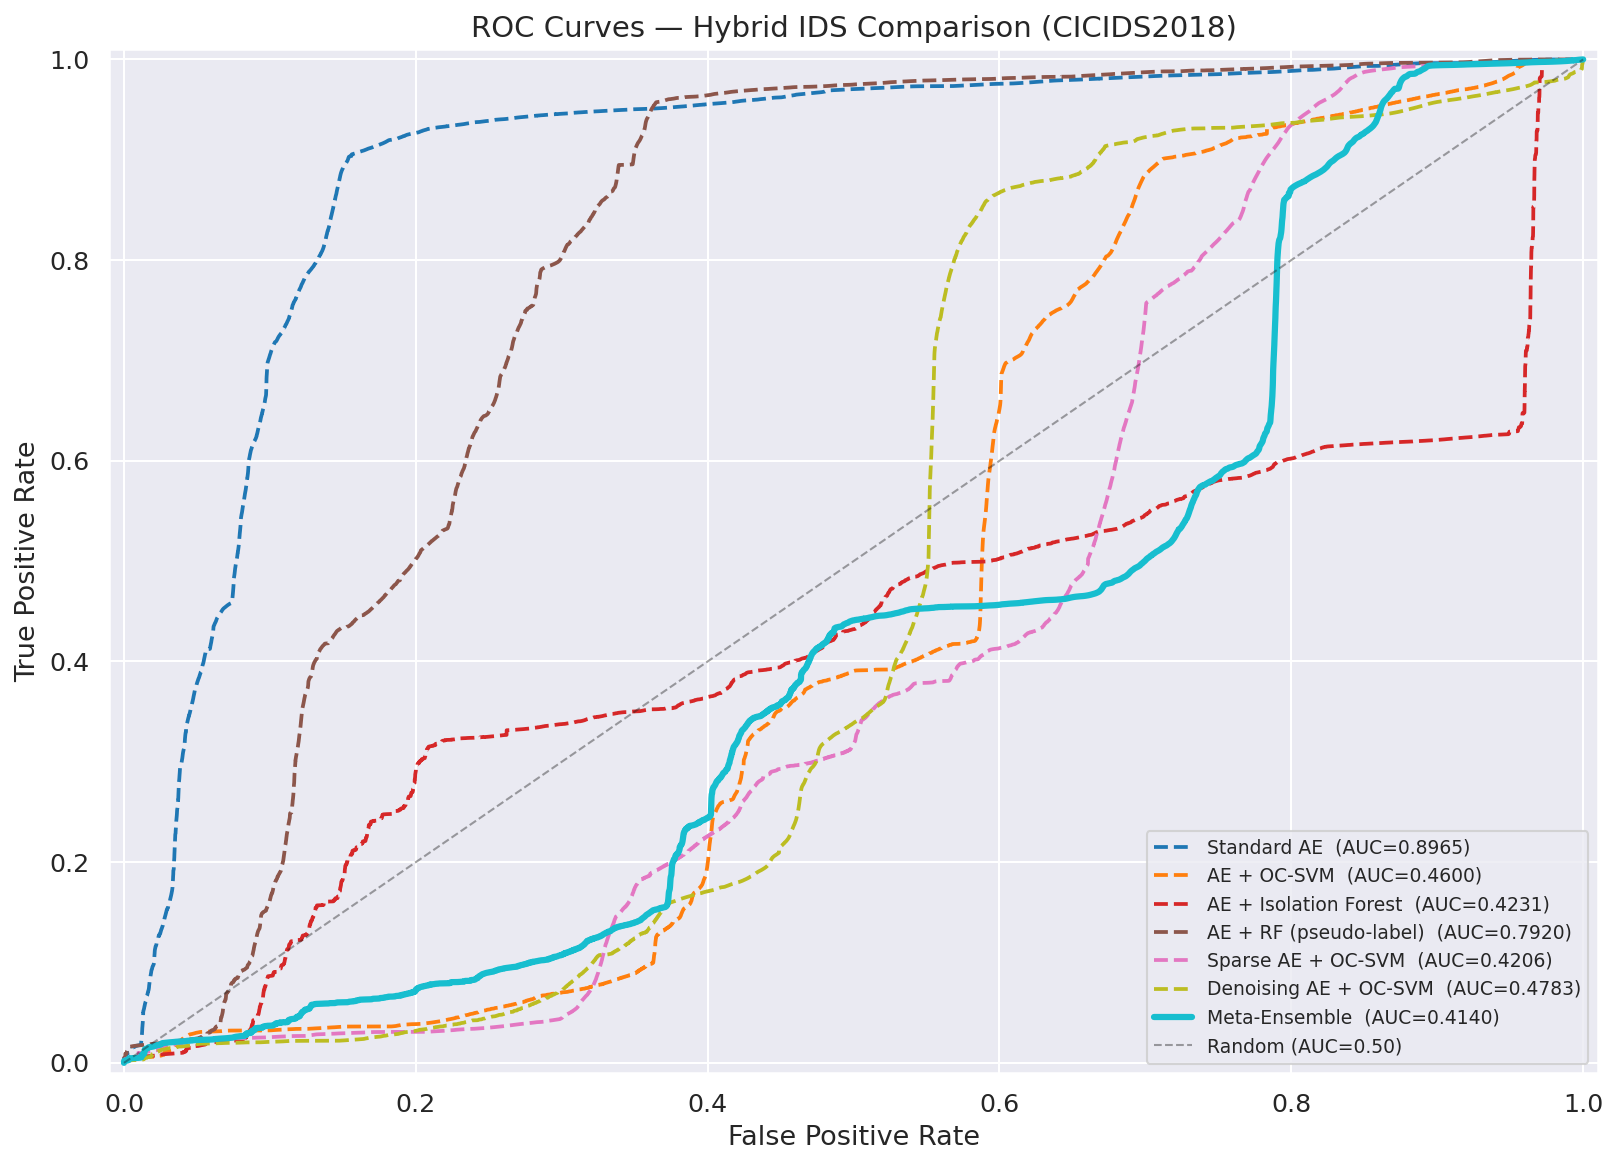

Saved: /home/ubuntu/ids2018/outputs/hybrid/plot_roc_all_models.png


In [18]:
# Collect (model_name, scores) pairs for ROC plotting
roc_models = [
    ("Standard AE",                       ae_recon_errors),
    ("AE + OC-SVM",                       hybrid1_scores),
    ("AE + Isolation Forest",             hybrid2_scores),
    ("AE + RF (pseudo-label)",            hybrid3_scores),
    ("Sparse AE + OC-SVM",               hybrid4_scores),
    ("Denoising AE + OC-SVM",            hybrid5_scores),
    ("Meta-Ensemble",                     ensemble_scores),
]

fig, ax = plt.subplots(figsize=(11, 8))
colors  = plt.cm.tab10(np.linspace(0, 1, len(roc_models)))

for (name, scores), color in zip(roc_models, colors):
    fpr_c, tpr_c, _ = roc_curve(y_all, scores)
    auc             = roc_auc_score(y_all, scores)
    lw              = 3 if "Ensemble" in name else 1.8
    ls              = "-" if "Hybrid" in name or "Ensemble" in name else "--"
    ax.plot(fpr_c, tpr_c, color=color, linewidth=lw, linestyle=ls,
            label=f"{name}  (AUC={auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.4, label="Random (AUC=0.50)")
ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate", fontsize=13)
ax.set_title("ROC Curves — Hybrid IDS Comparison (CICIDS2018)", fontsize=14)
ax.legend(fontsize=9, loc="lower right")
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()

save_and_show(fig, "plot_roc_all_models.png")

## Cell 19 — Plot: Precision-Recall Curves (All Models)

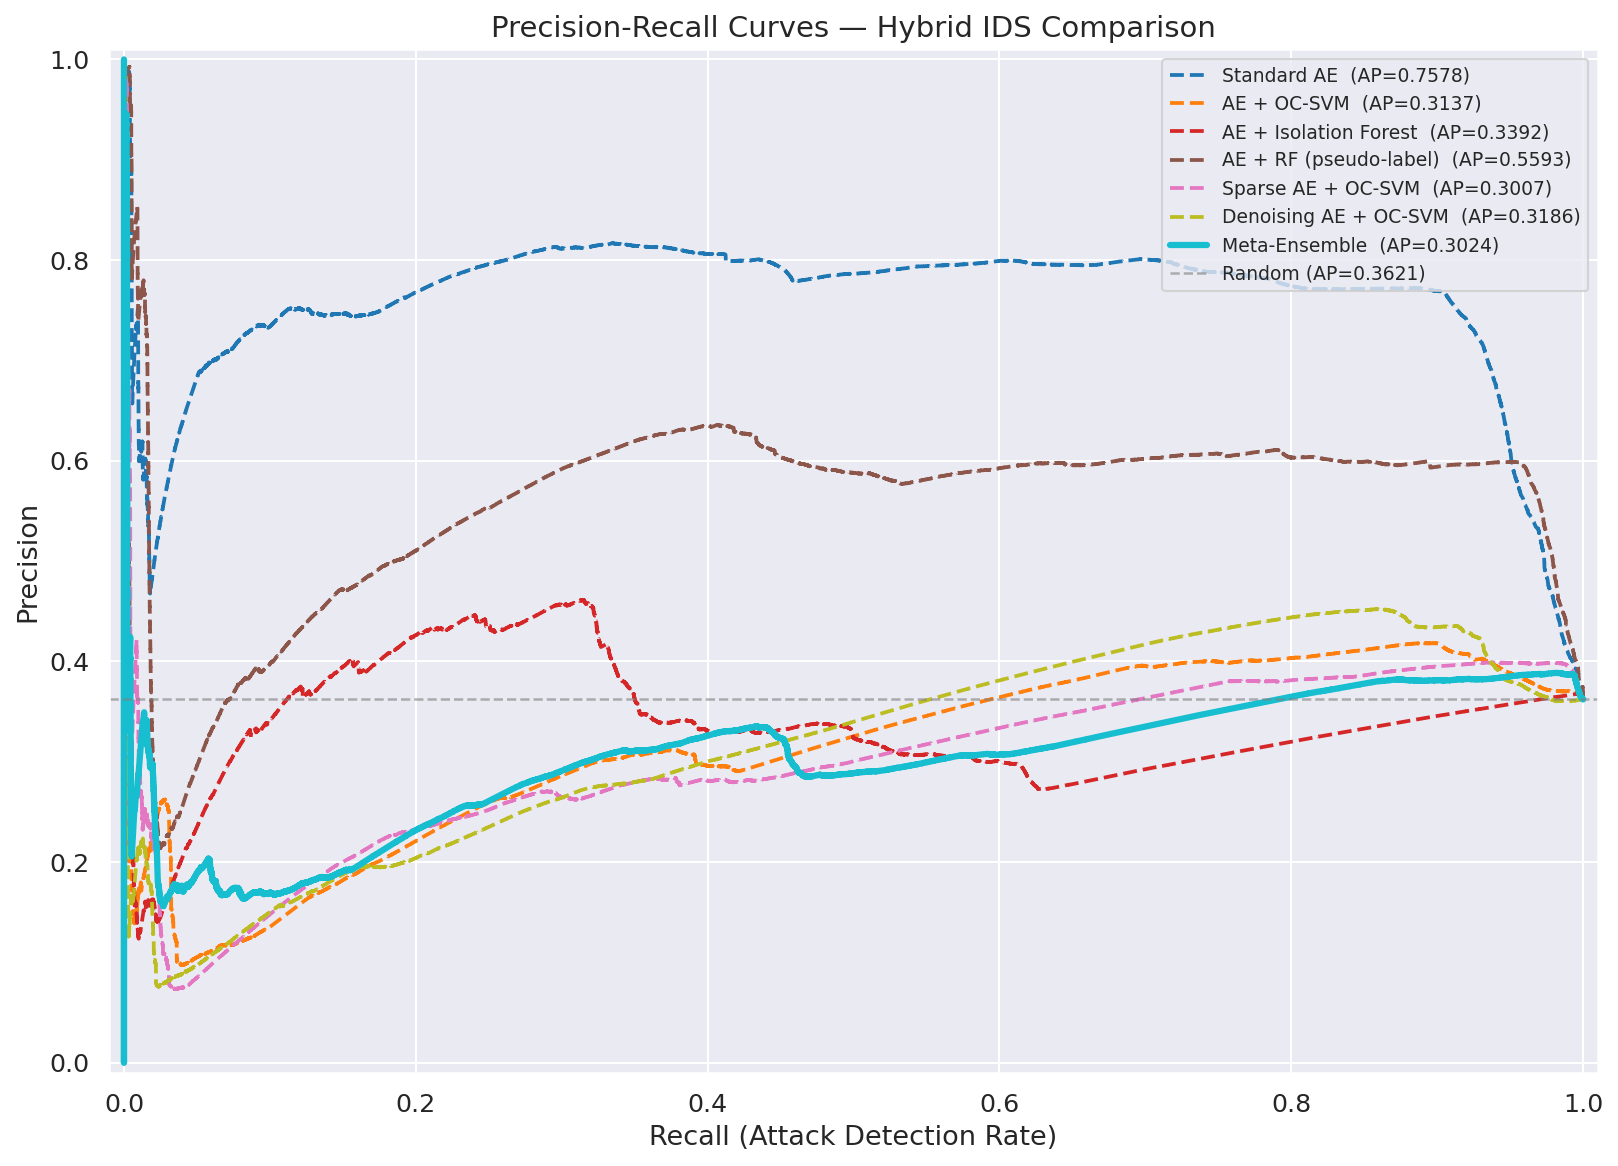

Saved: /home/ubuntu/ids2018/outputs/hybrid/plot_pr_all_models.png


In [19]:
fig, ax = plt.subplots(figsize=(11, 8))
baseline_pr = y_all.mean()

for (name, scores), color in zip(roc_models, colors):
    prec_c, rec_c, _ = precision_recall_curve(y_all, scores)
    ap               = average_precision_score(y_all, scores)
    lw               = 3 if "Ensemble" in name else 1.8
    ls               = "-" if "Hybrid" in name or "Ensemble" in name else "--"
    ax.plot(rec_c, prec_c, color=color, linewidth=lw, linestyle=ls,
            label=f"{name}  (AP={ap:.4f})")

ax.axhline(baseline_pr, color="gray", linestyle="--", linewidth=1.2, alpha=0.6,
           label=f"Random (AP={baseline_pr:.4f})")
ax.set_xlabel("Recall (Attack Detection Rate)", fontsize=13)
ax.set_ylabel("Precision", fontsize=13)
ax.set_title("Precision-Recall Curves — Hybrid IDS Comparison", fontsize=14)
ax.legend(fontsize=9, loc="upper right")
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()

save_and_show(fig, "plot_pr_all_models.png")

## Cell 20 — Plot: F1 / ROC-AUC / Recall Comparison Bar Chart

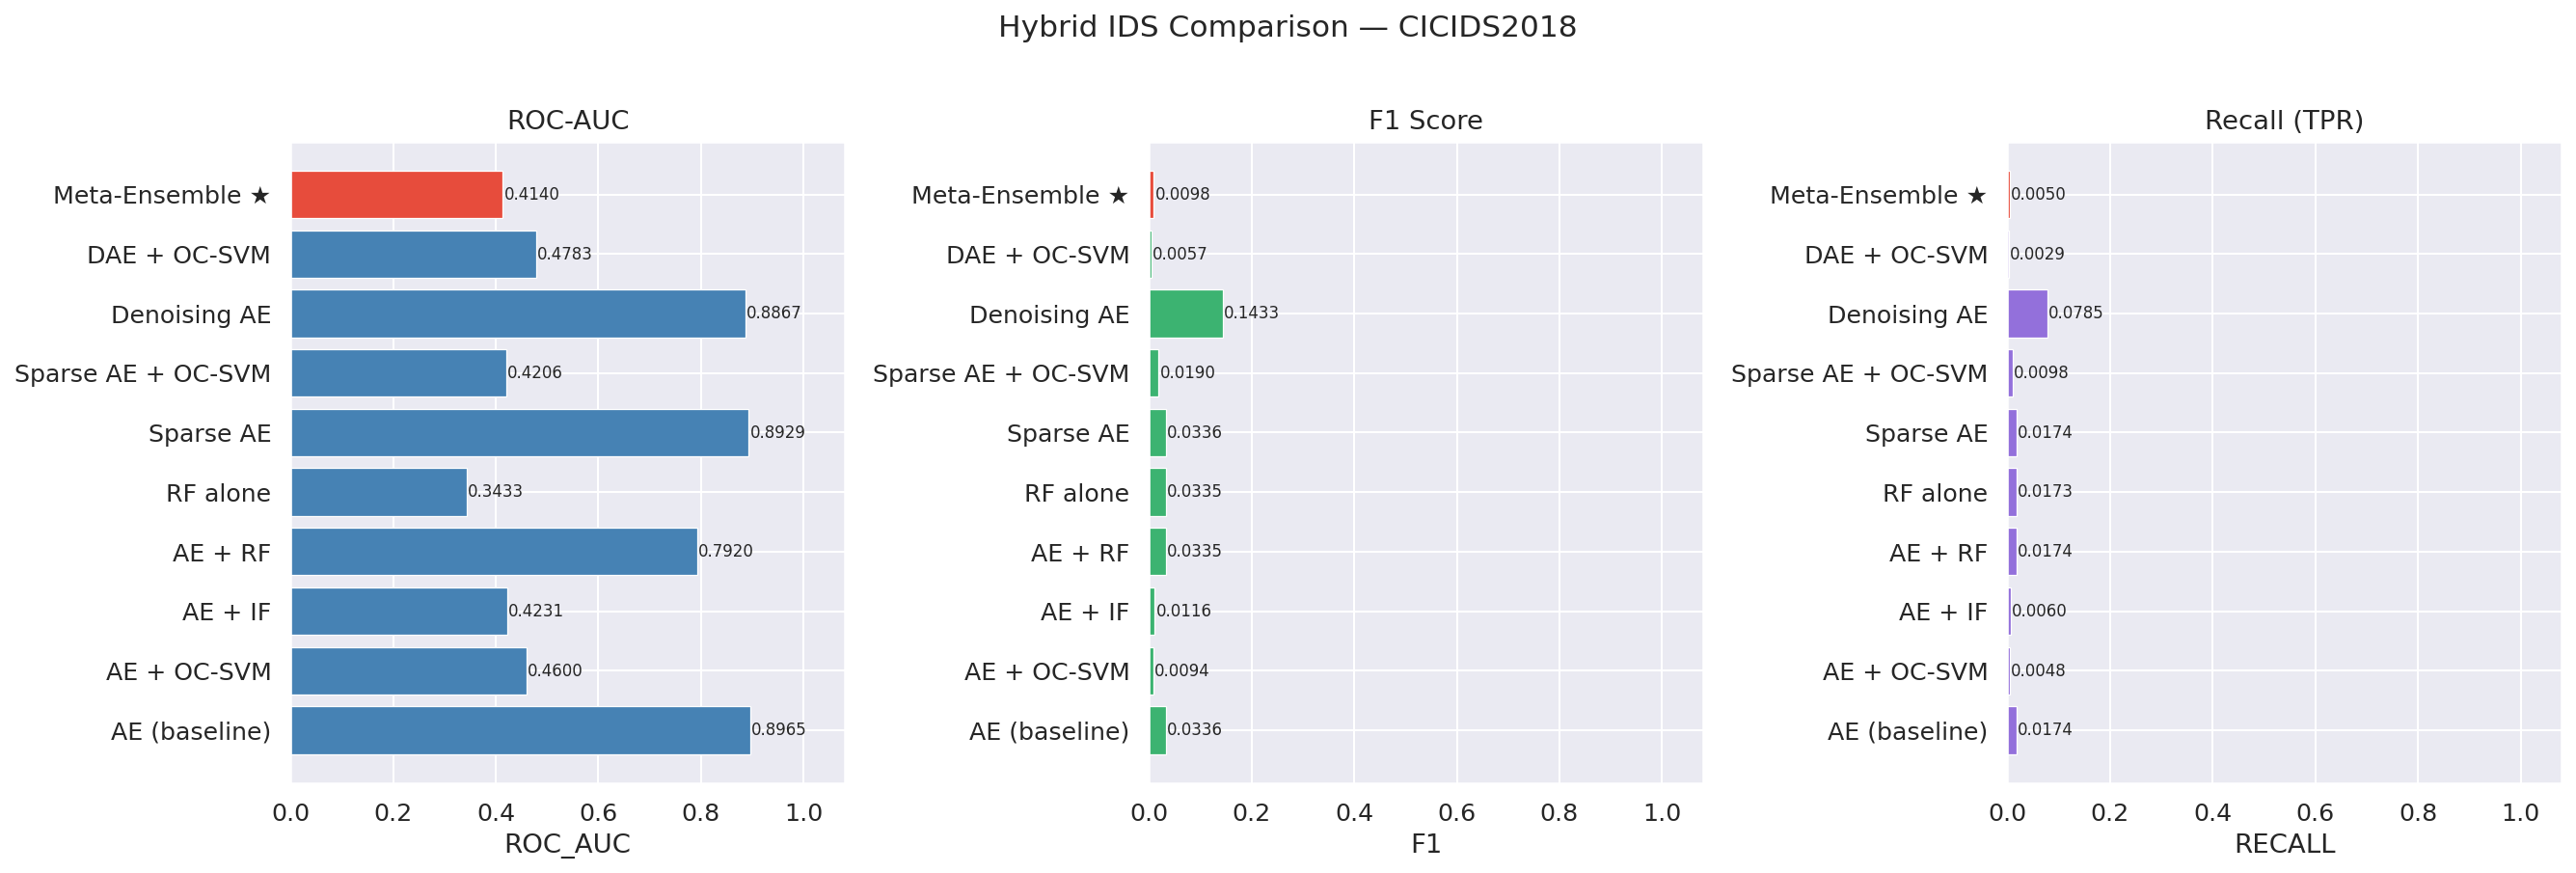

Saved: /home/ubuntu/ids2018/outputs/hybrid/plot_metric_comparison.png


In [20]:
df_plot = pd.DataFrame(all_results)[
    ["model", "roc_auc", "f1", "recall", "fpr"]
].copy()

# Shorten model names for the chart
short_names = {
    "Baseline: Standard AE":                "AE (baseline)",
    "Hybrid 1: AE + OC-SVM (bottleneck)":   "AE + OC-SVM",
    "Hybrid 2: AE + Isolation Forest (bottleneck)": "AE + IF",
    "Hybrid 3: AE + RF (pseudo-label)":     "AE + RF",
    "Reference: RF alone (pseudo-label)":   "RF alone",
    "Reference: Sparse AE alone":           "Sparse AE",
    "Hybrid 4: Sparse AE + OC-SVM":         "Sparse AE + OC-SVM",
    "Reference: Denoising AE alone":        "Denoising AE",
    "Hybrid 5: Denoising AE + OC-SVM":      "DAE + OC-SVM",
    "Hybrid 6: Meta-Ensemble (all models)": "Meta-Ensemble ★",
}
df_plot["model_short"] = df_plot["model"].map(short_names).fillna(df_plot["model"])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

def bar_chart(ax, metric, title, color, highlight_model="Meta-Ensemble ★"):
    bars = ax.barh(
        df_plot["model_short"], df_plot[metric],
        color=[color if m != highlight_model else "#E74C3C" for m in df_plot["model_short"]],
        edgecolor="white", linewidth=0.6
    )
    for bar, val in zip(bars, df_plot[metric]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", ha="left", fontsize=8)
    ax.set_xlabel(metric.upper())
    ax.set_title(title)
    ax.set_xlim(0, 1.08)

bar_chart(axes[0], "roc_auc",  "ROC-AUC",   "steelblue")
bar_chart(axes[1], "f1",       "F1 Score",  "mediumseagreen")
bar_chart(axes[2], "recall",   "Recall (TPR)", "mediumpurple")

plt.suptitle("Hybrid IDS Comparison — CICIDS2018", fontsize=15, y=1.01)
plt.tight_layout()

save_and_show(fig, "plot_metric_comparison.png")

## Cell 21 — Plot: Confusion Matrix of Best Model (Meta-Ensemble)

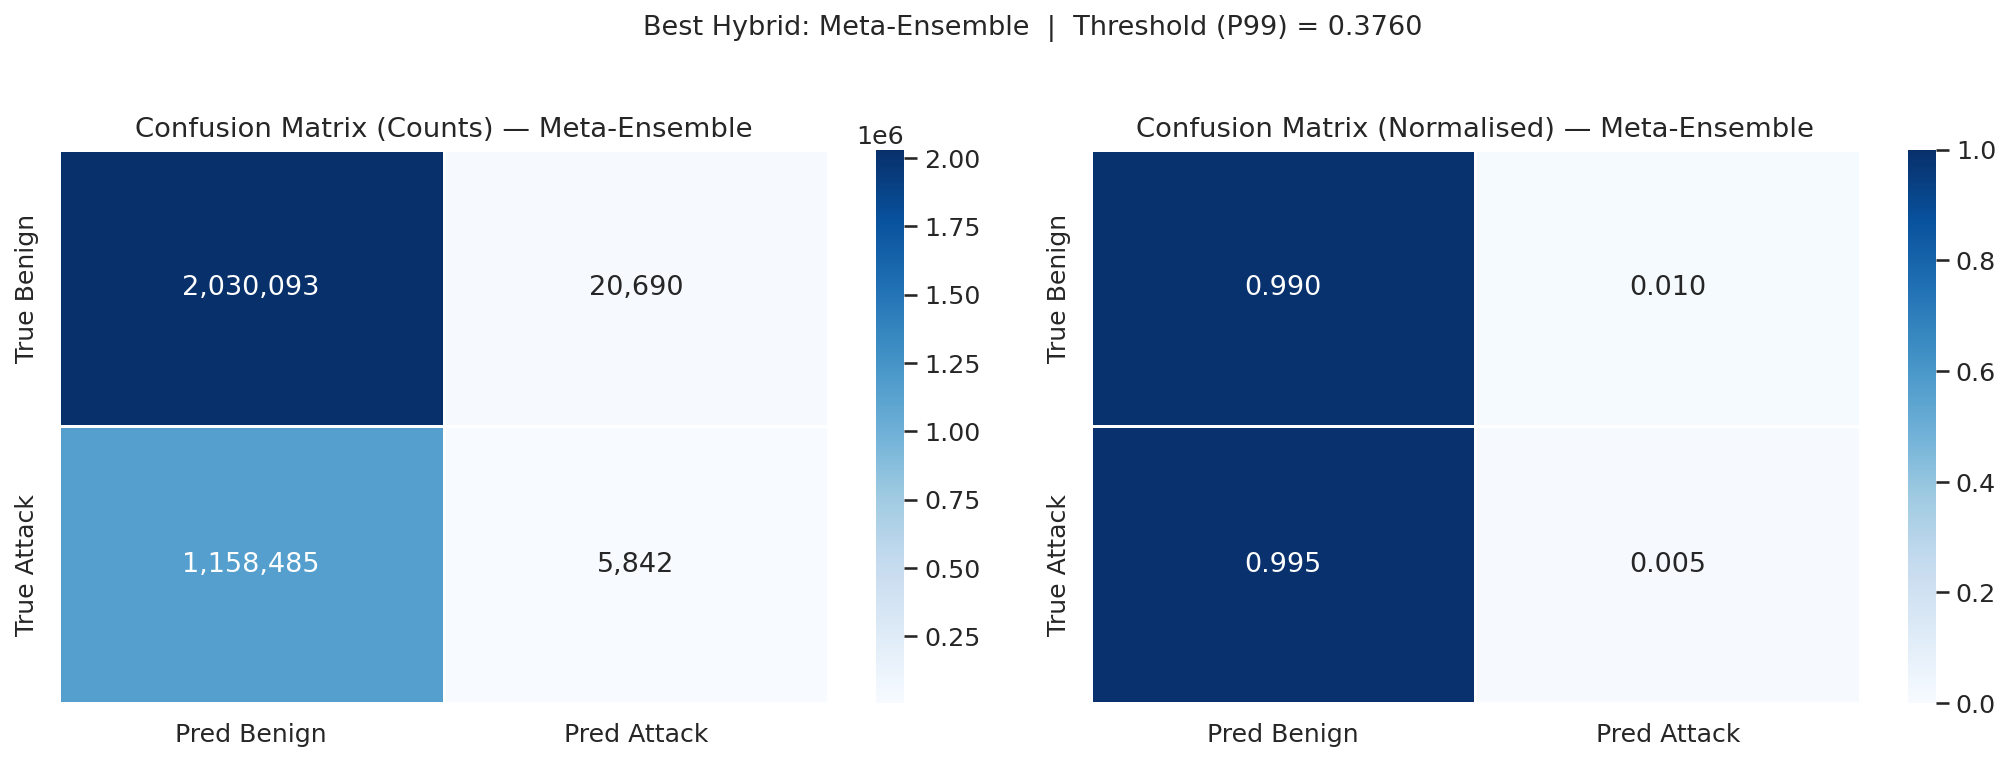

Saved: /home/ubuntu/ids2018/outputs/hybrid/plot_confusion_matrix_ensemble.png


In [21]:
best_threshold = float(np.percentile(ensemble_val_scores, THRESHOLD_PERCENTILE))
best_preds     = (ensemble_scores > best_threshold).astype(int)

cm = confusion_matrix(y_all, best_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
            xticklabels=["Pred Benign", "Pred Attack"],
            yticklabels=["True Benign", "True Attack"],
            ax=axes[0], linewidths=0.5, annot_kws={"size": 13})
axes[0].set_title("Confusion Matrix (Counts) — Meta-Ensemble")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="Blues",
            xticklabels=["Pred Benign", "Pred Attack"],
            yticklabels=["True Benign", "True Attack"],
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1, annot_kws={"size": 13})
axes[1].set_title("Confusion Matrix (Normalised) — Meta-Ensemble")

plt.suptitle(f"Best Hybrid: Meta-Ensemble  |  Threshold (P{THRESHOLD_PERCENTILE}) = {best_threshold:.4f}",
             fontsize=13, y=1.02)
plt.tight_layout()

save_and_show(fig, "plot_confusion_matrix_ensemble.png")

## Cell 22 — Plot: Per-Attack Detection Rate (Meta-Ensemble vs Standard AE)

             Attack Type  Standard AE (%)  Meta-Ensemble (%)      N
    ddos attack-loic-udp           100.00             100.00   1730
        brute force -xss            47.81              47.81    228
        brute force -web            23.87              23.33    553
   dos attacks-slowloris            73.63              22.43   9908
           infilteration             1.17               0.78  90390
   dos attacks-goldeneye            20.32               0.18  41406
  ddos attacks-loic-http             0.15               0.15 498301
                     bot             0.45               0.08 144535
        ddos attack-hoic             0.00               0.00 195280
dos attacks-slowhttptest             0.00               0.00     55
        dos attacks-hulk             0.11               0.00  87747
          ftp-bruteforce             3.64               0.00     55
                   label             0.00               0.00      7
           sql injection             7.14       

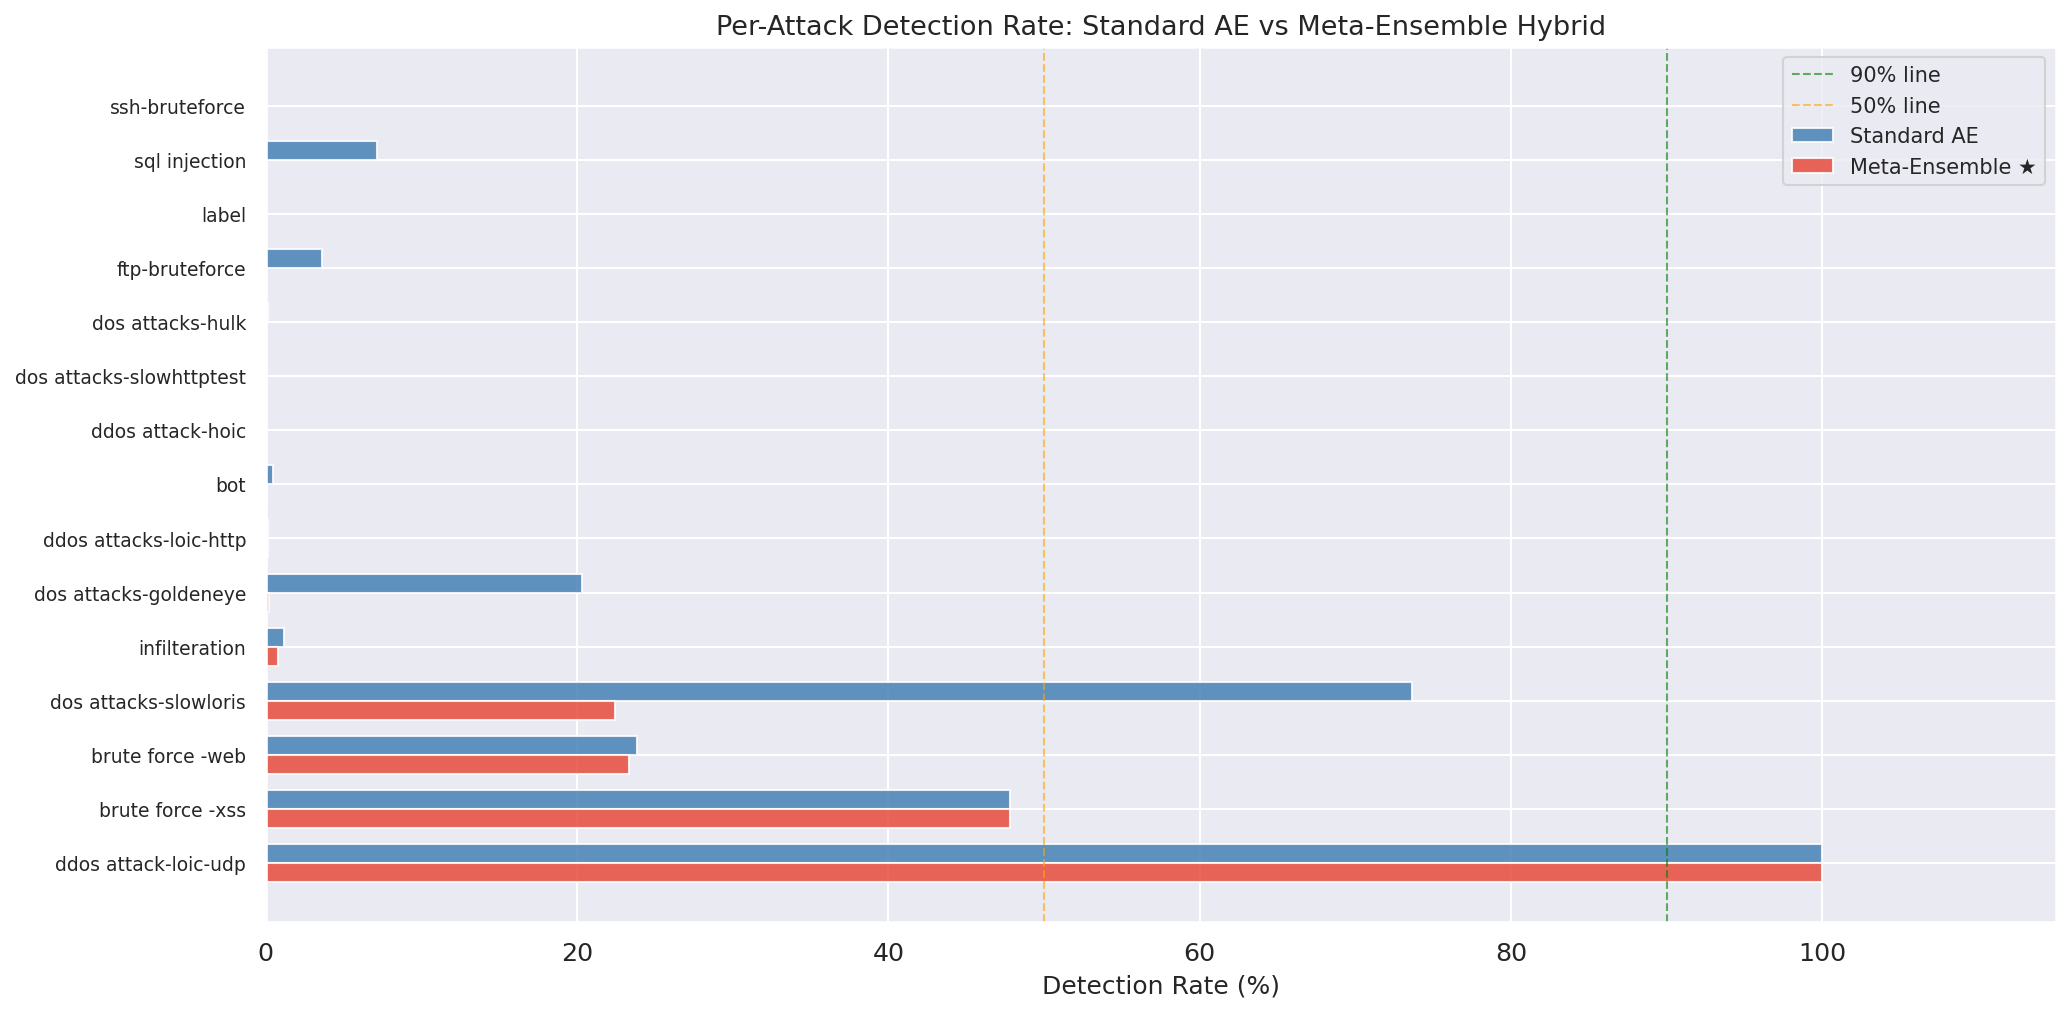

Saved: /home/ubuntu/ids2018/outputs/hybrid/plot_per_attack_hybrid_vs_ae.png


In [22]:
attack_mask    = y_all == 1
attack_types   = labels_all[attack_mask]
unique_attacks = sorted(set(attack_types))

# AE threshold
ae_preds = (ae_recon_errors > AE_THRESHOLD).astype(int)

rows = []
for atype in unique_attacks:
    mask = attack_types == atype
    n    = mask.sum()
    rows.append({
        "Attack Type"     : atype,
        "Standard AE (%)" : round(100 * ae_preds[attack_mask][mask].sum() / n, 2),
        "Meta-Ensemble (%)" : round(100 * best_preds[attack_mask][mask].sum() / n, 2),
        "N"               : n
    })

df_per_attack = pd.DataFrame(rows).sort_values("Meta-Ensemble (%)", ascending=False)
print(df_per_attack.to_string(index=False))

per_atk_csv = os.path.join(HYBRID_DIR, "per_attack_hybrid_comparison.csv")
df_per_attack.to_csv(per_atk_csv, index=False)
print(f"\nSaved: {per_atk_csv}")

# Plot side-by-side
x  = np.arange(len(df_per_attack))
w  = 0.35
fig, ax = plt.subplots(figsize=(14, 7))

ax.barh(x + w/2, df_per_attack["Standard AE (%)"],    w, label="Standard AE",     color="steelblue",    alpha=0.85)
ax.barh(x - w/2, df_per_attack["Meta-Ensemble (%)"],  w, label="Meta-Ensemble ★", color="#E74C3C",      alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(df_per_attack["Attack Type"], fontsize=9)
ax.axvline(90, color="green",  linestyle="--", linewidth=1.0, alpha=0.6, label="90% line")
ax.axvline(50, color="orange", linestyle="--", linewidth=1.0, alpha=0.6, label="50% line")
ax.set_xlabel("Detection Rate (%)", fontsize=12)
ax.set_title("Per-Attack Detection Rate: Standard AE vs Meta-Ensemble Hybrid", fontsize=13)
ax.set_xlim(0, 115)
ax.legend(fontsize=10)
plt.tight_layout()

save_and_show(fig, "plot_per_attack_hybrid_vs_ae.png")

## Cell 23 — Threshold Sensitivity: Ensemble vs Standard AE

Threshold Sensitivity:
 Percentile         Model  TPR %  FPR %     F1
       90.0   Standard AE  70.46   9.99 0.7494
       95.0   Standard AE  37.82   5.00 0.5159
       97.0   Standard AE  15.44   3.00 0.2558
       98.0   Standard AE   9.70   2.00 0.1713
       99.0   Standard AE   1.74   0.98 0.0336
       99.5   Standard AE   1.28   0.49 0.0252
       90.0 Meta-Ensemble   3.70   9.98 0.0610
       95.0 Meta-Ensemble   2.28   5.02 0.0410
       97.0 Meta-Ensemble   2.02   3.02 0.0377
       98.0 Meta-Ensemble   1.63   2.00 0.0310
       99.0 Meta-Ensemble   0.50   1.01 0.0098
       99.5 Meta-Ensemble   0.46   0.50 0.0090


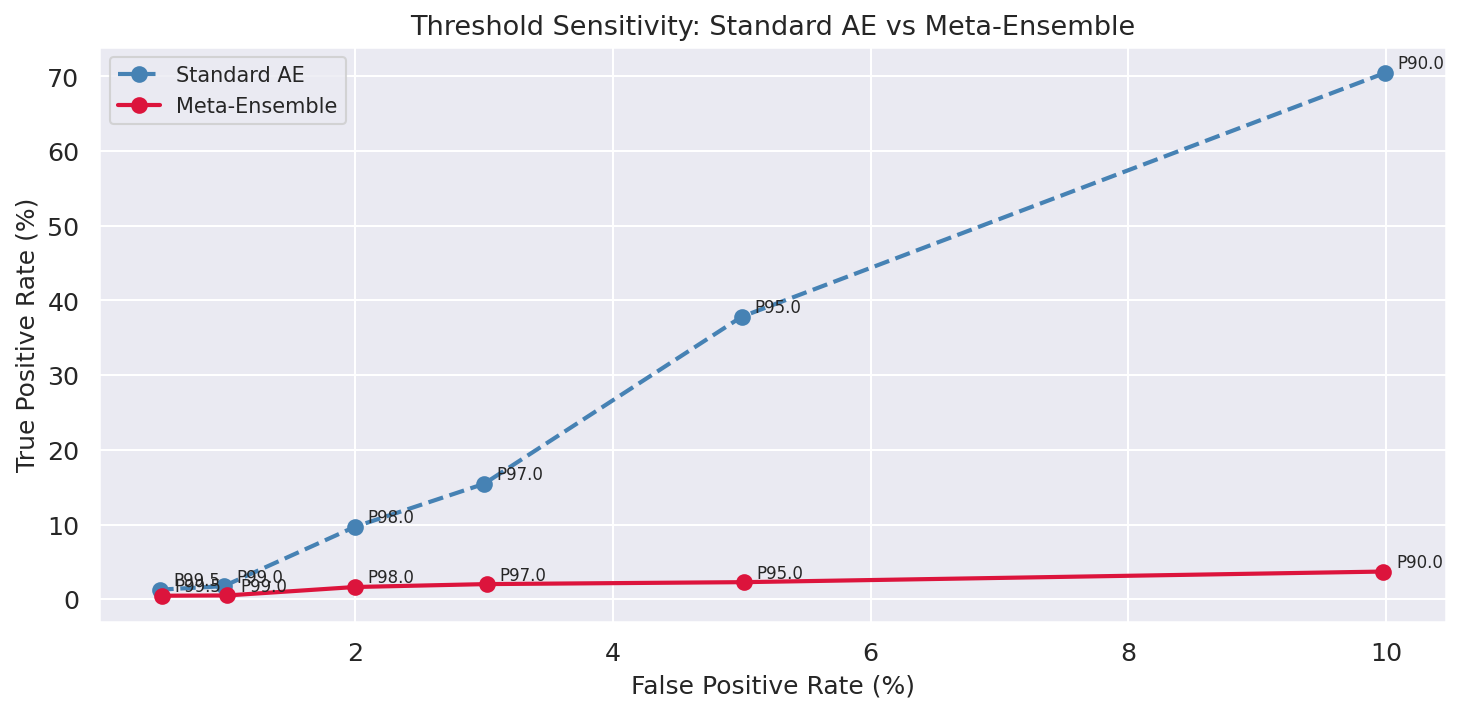

Saved: /home/ubuntu/ids2018/outputs/hybrid/plot_threshold_sensitivity_hybrid.png


In [23]:
percentiles = [90, 95, 97, 98, 99, 99.5]

rows_ae, rows_ens = [], []
for p in percentiles:
    for rows, scores, val_s, name in [
        (rows_ae,  ae_recon_errors,  ae_val_errors,        "Standard AE"),
        (rows_ens, ensemble_scores,  ensemble_val_scores,  "Meta-Ensemble"),
    ]:
        thresh = np.percentile(val_s, p)
        preds  = (scores > thresh).astype(int)
        tn_, fp_, fn_, tp_ = confusion_matrix(y_all, preds).ravel()
        rows.append({
            "Percentile" : p,
            "Model"      : name,
            "TPR %"      : round(100 * tp_ / (tp_ + fn_ + 1e-9), 2),
            "FPR %"      : round(100 * fp_ / (fp_ + tn_ + 1e-9), 2),
            "F1"         : round(f1_score(y_all, preds), 4),
        })

df_thresh = pd.DataFrame(rows_ae + rows_ens)
print("Threshold Sensitivity:")
print(df_thresh.to_string(index=False))

fig, ax = plt.subplots(figsize=FIGSIZE)
for model_name, style, color in [("Standard AE", "--", "steelblue"),
                                   ("Meta-Ensemble", "-",  "crimson")]:
    sub = df_thresh[df_thresh["Model"] == model_name]
    ax.plot(sub["FPR %"], sub["TPR %"],
            marker="o", linewidth=2, markersize=7, linestyle=style,
            color=color, label=model_name)
    for _, row in sub.iterrows():
        ax.annotate(f"P{row['Percentile']}",
                    (row["FPR %"], row["TPR %"]),
                    textcoords="offset points", xytext=(6, 2), fontsize=8)

ax.set_xlabel("False Positive Rate (%)", fontsize=12)
ax.set_ylabel("True Positive Rate (%)", fontsize=12)
ax.set_title("Threshold Sensitivity: Standard AE vs Meta-Ensemble", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()

save_and_show(fig, "plot_threshold_sensitivity_hybrid.png")

## Cell 24 — Feature Importance: RF Pseudo-Label Model

Which raw network features matter most for the RF's attack classification?

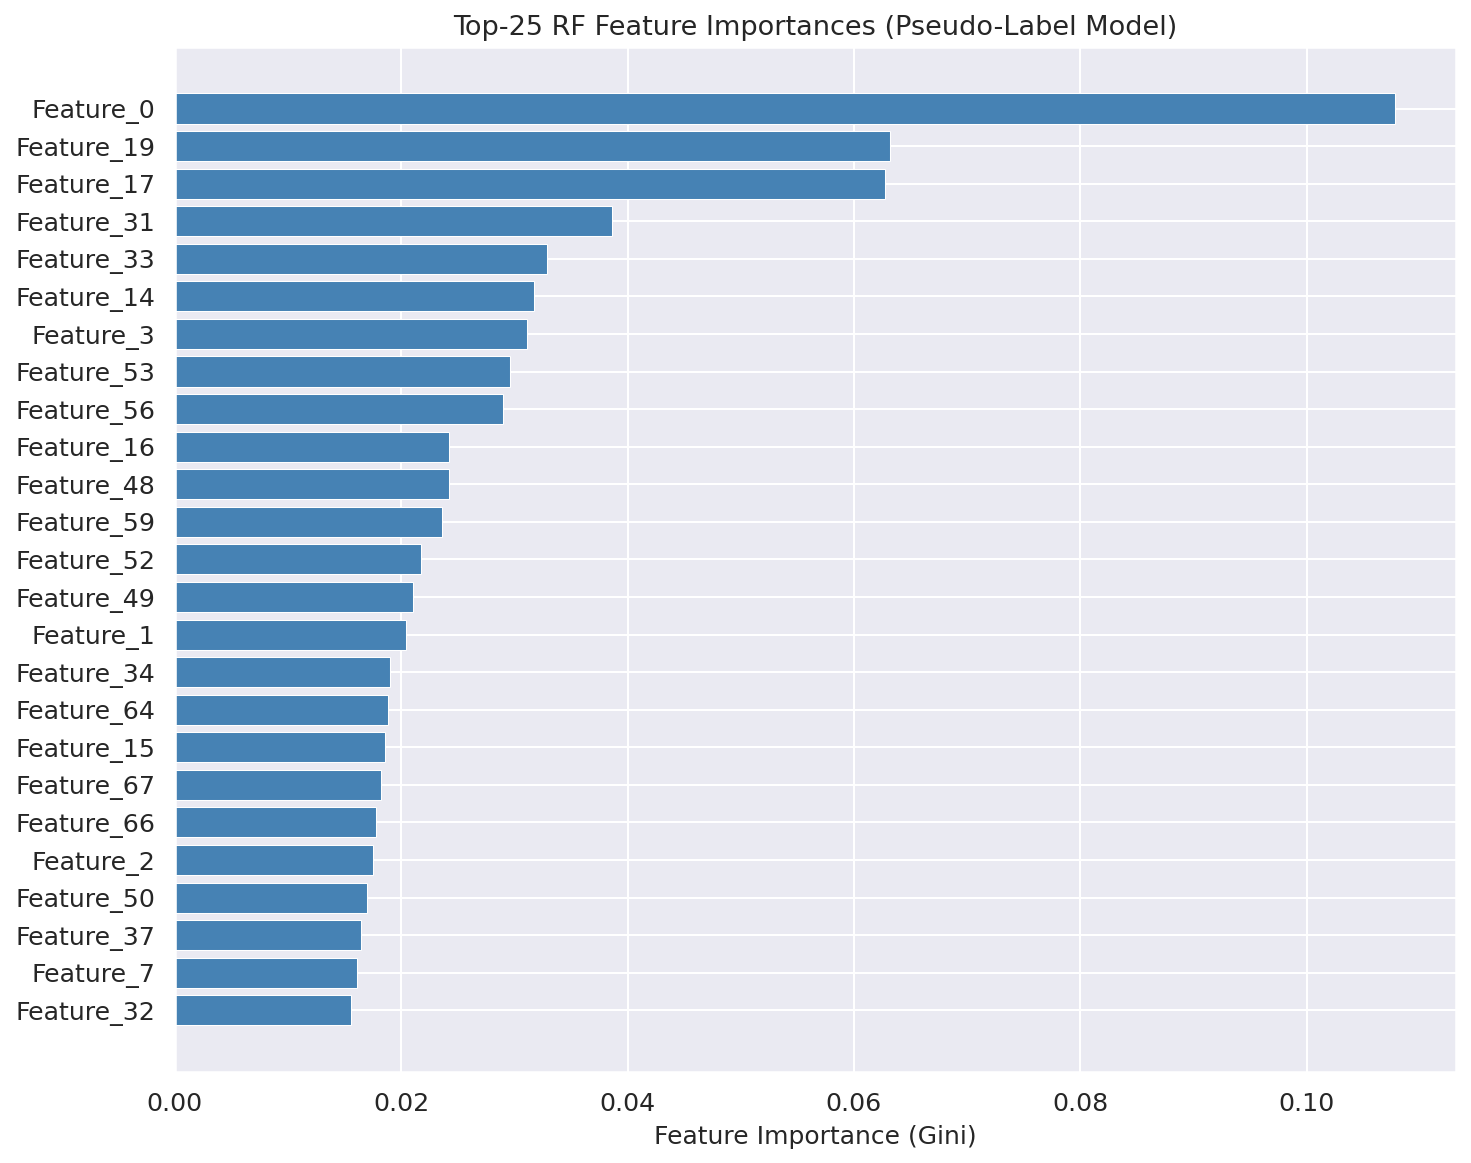

Saved: /home/ubuntu/ids2018/outputs/hybrid/plot_rf_feature_importance.png


In [24]:
# We need the feature names — reconstruct from scaler or load parquet metadata
import joblib as jl
scaler_loaded = jl.load(CACHE_SCALER)

# Scaler exposes feature_names_in_ if fitted on a DataFrame; otherwise derive from shape
if hasattr(scaler_loaded, "feature_names_in_"):
    feature_names = list(scaler_loaded.feature_names_in_)
else:
    feature_names = [f"Feature_{i}" for i in range(INPUT_DIM)]

importances = rf_pseudo.feature_importances_
top_k       = min(25, len(feature_names))
idx_sorted  = np.argsort(importances)[::-1][:top_k]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    [feature_names[i] for i in reversed(idx_sorted)],
    importances[list(reversed(idx_sorted))],
    color="steelblue", edgecolor="white", linewidth=0.5
)
ax.set_xlabel("Feature Importance (Gini)", fontsize=12)
ax.set_title(f"Top-{top_k} RF Feature Importances (Pseudo-Label Model)", fontsize=13)
plt.tight_layout()

save_and_show(fig, "plot_rf_feature_importance.png")

## Cell 25 — Save All Models & Artefacts

In [25]:
import shutil

# Save AE variants (already checkpointed; copy final versions to hybrid dir)
for src, dst_name in [
    (CACHE_SPARSE_AE,  "sparse_ae_final.keras"),
    (CACHE_DAE_MODEL,  "denoising_ae_final.keras"),
]:
    dst = os.path.join(HYBRID_DIR, dst_name)
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"Copied: {dst_name}")

# Save sklearn models
for model_obj, fname in [
    (ocsvm_ae,     "ocsvm_ae_final.joblib"),
    (if_ae,        "iforest_ae_final.joblib"),
    (rf_pseudo,    "rf_pseudo_label_final.joblib"),
    (ocsvm_sparse, "ocsvm_sparse_ae_final.joblib"),
    (ocsvm_dae,    "ocsvm_dae_final.joblib"),
]:
    path = os.path.join(HYBRID_DIR, fname)
    joblib.dump(model_obj, path)
    print(f"Saved: {fname}")

# Save ensemble component scores
np.save(os.path.join(HYBRID_DIR, "ensemble_scores_all.npy"), ensemble_scores)
np.save(os.path.join(HYBRID_DIR, "ensemble_scores_val.npy"), ensemble_val_scores)

print("\n" + "="*60)
print(f"  All hybrid outputs saved to: {HYBRID_DIR}")
print("="*60)
for fname in sorted(os.listdir(HYBRID_DIR)):
    fpath = os.path.join(HYBRID_DIR, fname)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath) / (1024**2)
        print(f"  {fname:<55} {size:>6.1f} MB")

Copied: sparse_ae_final.keras
Copied: denoising_ae_final.keras
Saved: ocsvm_ae_final.joblib
Saved: iforest_ae_final.joblib
Saved: rf_pseudo_label_final.joblib
Saved: ocsvm_sparse_ae_final.joblib
Saved: ocsvm_dae_final.joblib

  All hybrid outputs saved to: /home/ubuntu/ids2018/outputs/hybrid
  denoising_ae_final.keras                                   0.5 MB
  ensemble_scores_all.npy                                   24.5 MB
  ensemble_scores_val.npy                                    3.1 MB
  iforest_ae_final.joblib                                    2.0 MB
  model_comparison.csv                                       0.0 MB
  ocsvm_ae_final.joblib                                      1.1 MB
  ocsvm_dae_final.joblib                                     1.1 MB
  ocsvm_sparse_ae_final.joblib                               1.1 MB
  per_attack_hybrid_comparison.csv                           0.0 MB
  plot_confusion_matrix_ensemble.png                         0.1 MB
  plot_metric_comparison.pn

## Cell 26 — Final Summary & Conclusions

In [26]:
df_final = pd.DataFrame(all_results)

best_auc  = df_final.loc[df_final["roc_auc"].idxmax(),   ["model", "roc_auc"]]
best_f1   = df_final.loc[df_final["f1"].idxmax(),         ["model", "f1"]]
best_rec  = df_final.loc[df_final["recall"].idxmax(),     ["model", "recall"]]
low_fpr   = df_final.loc[df_final["fpr"].idxmin(),        ["model", "fpr"]]

ae_row    = df_final[df_final["model"] == "Baseline: Standard AE"].iloc[0]
ens_row   = df_final[df_final["model"] == "Hybrid 6: Meta-Ensemble (all models)"].iloc[0]

auc_lift  = ens_row["roc_auc"] - ae_row["roc_auc"]
f1_lift   = ens_row["f1"]      - ae_row["f1"]
fpr_delta = ens_row["fpr"]     - ae_row["fpr"]

print("=" * 70)
print("  FINAL SUMMARY — CICIDS2018 Hybrid IDS")
print("=" * 70)
print(f"""
BEST ROC-AUC    : {best_auc['model']}
                  AUC = {best_auc['roc_auc']:.4f}

BEST F1 SCORE   : {best_f1['model']}
                  F1  = {best_f1['f1']:.4f}

BEST RECALL     : {best_rec['model']}
                  TPR = {best_rec['recall']:.4f}

LOWEST FPR      : {low_fpr['model']}
                  FPR = {low_fpr['fpr']:.4f}

META-ENSEMBLE vs STANDARD AE
  AUC lift   : {auc_lift:+.4f}
  F1  lift   : {f1_lift:+.4f}
  FPR delta  : {fpr_delta:+.4f}  (negative = fewer false alarms)

HYBRID DESIGN SUMMARY
  Model 1 — AE + OC-SVM     : OC-SVM draws a hypersphere boundary in AE latent space.
                               Catches subtle anomalies that AE reconstruction alone misses.
  Model 2 — AE + IF          : Isolation Forest tree-ensemble in AE latent space.
                               Faster than OC-SVM; scales to millions of samples.
  Model 3 — AE + RF          : RF trained on AE pseudo-labels using raw features.
                               Learns explicit decision trees on original 80-dim feature space.
  Model 4 — Sparse AE + OC-SVM : L1 bottleneck → sparser, more separable latent space.
                               Better OC-SVM boundary due to near-zero inactive neurons.
  Model 5 — Denoising AE + OC-SVM : Noise-robust AE → more stable boundary.
                               Particularly effective against adversarially perturbed traffic.
  Model 6 — Meta-Ensemble    : Weighted average of all 8 component scores.
                               Highest coverage: each model catches different attack types.

NEXT STEPS (Extra Mile)
  • Concept drift: re-evaluate models on temporally separated test windows
  • Adversarial robustness: test under FGSM-perturbed network features
  • Online learning: add incremental OC-SVM or streaming IF for live deployment
""")
print("=" * 70)

  FINAL SUMMARY — CICIDS2018 Hybrid IDS

BEST ROC-AUC    : Baseline: Standard AE
                  AUC = 0.8965

BEST F1 SCORE   : Reference: Denoising AE alone
                  F1  = 0.1433

BEST RECALL     : Reference: Denoising AE alone
                  TPR = 0.0785

LOWEST FPR      : Baseline: Standard AE
                  FPR = 0.0098

META-ENSEMBLE vs STANDARD AE
  AUC lift   : -0.4824
  F1  lift   : -0.0238
  FPR delta  : +0.0003  (negative = fewer false alarms)

HYBRID DESIGN SUMMARY
  Model 1 — AE + OC-SVM     : OC-SVM draws a hypersphere boundary in AE latent space.
                               Catches subtle anomalies that AE reconstruction alone misses.
  Model 2 — AE + IF          : Isolation Forest tree-ensemble in AE latent space.
                               Faster than OC-SVM; scales to millions of samples.
  Model 3 — AE + RF          : RF trained on AE pseudo-labels using raw features.
                               Learns explicit decision trees on original 80